In [1]:
import pandas as pd

xls = pd.read_excel(
    '../ParleysRWIS_20211101-20230430.xlsx',
    sheet_name=['RwisAtmosphericData', 'RwisSurfaceData'],
    parse_dates=['SampleTime'],    # ← ensure this column is parsed as full datetime
    engine='openpyxl'
)

df1 = xls['RwisAtmosphericData']
df2 = xls['RwisSurfaceData']

# merge
df1['SampleTime'] = pd.to_datetime(df1['SampleTime'])
df2['SampleTime'] = pd.to_datetime(df2['SampleTime'])

df1['RwisControllerIntId'] = df1['RwisControllerIntId'].astype(str)
df2['RwisControllerIntId'] = df2['RwisControllerIntId'].astype(str)

df_merged = pd.merge(
    df1,
    df2,
    on=['SampleTime', 'RwisControllerIntId'],
    how='inner',
    suffixes=('_atm','_surf')
)



In [2]:
cols_to_drop = ['Pressure', 'SnowIntervalDepth', 'PrecipitationIntervalAmount','PrecipitationAmount',
                'RoadStatusText','iceCurCondIndex','iceAvgCondIndex','iceCurCondCode','iceAvgCondCode',
               'iceCurFricIndex','iceAvgFricIndex','iceCurFricCode','iceAvgFricCode','iceGrip','iceXValue',
               'iceYValue','iceYXRatio','iceLens','SurfaceSensorError','SurfaceSalinity','SurfaceFreezePoint','RoadStatus',
               'RoadStatus','RoadTemp','iceRoadTemp','RwisAtmoEquipmentIntId','WindSpeedGustTimestamp',
               'RwisSurfaceEquipmentIntId','WindDirection','WindSpeedAverage','WindSpeedGust','Visibility',
                'BatteryVoltage','dstInputVoltage','dstHardwareStatus','SurfaceStatusText','dscRoadStatusText','SubSurfaceTemp',
               'AirTemp_atm','DewPoint_atm','RelativeHumidity_atm','dscLevelOfGrip','dstRoadTemp'] 
df_merged_1 = df_merged.drop(columns=cols_to_drop)
df_merged_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 510142 entries, 0 to 510141
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              510142 non-null  datetime64[ns]
 1   RwisControllerIntId     510142 non-null  object        
 2   PrecipitationIntensity  45706 non-null   object        
 3   SnowDepth               115089 non-null  float64       
 4   SolarRadiation          434049 non-null  float64       
 5   PrecipitationType       508441 non-null  object        
 6   WetBulbTemp             509154 non-null  float64       
 7   SnowfallRate            510142 non-null  float64       
 8   WinterRoadWeatherIndex  503682 non-null  float64       
 9   RainTotal               510142 non-null  float64       
 10  StormIntensityIndex     500135 non-null  float64       
 11  PerformanceMetric       503605 non-null  float64       
 12  SurfaceStatus           506373

<AxesSubplot:>

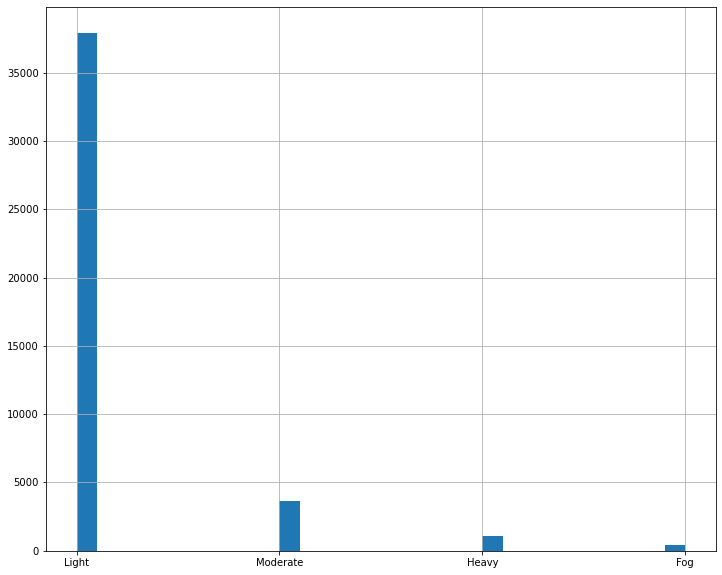

In [27]:
# Cell 4: histograms for all numeric columns
import matplotlib.pyplot as plt
%matplotlib inline

# Remove rows where PrecipitationIntensity is 'fog'
df_merged_1 = df_merged_1[df_merged_1['PrecipitationIntensity'] != 'fog']
# Remove rows where WetBulbTemp < -100
df_merged_1 = df_merged_1[df_merged_1['WetBulbTemp'] >= -100]
df_merged_1 = df_merged_1[df_merged_1['SurfaceTemp'] < 200]
df_merged_1 = df_merged_1[df_merged_1['AirTemp_surf'] < 100]
df_merged_1 = df_merged_1[df_merged_1['DewPoint_surf'] < 80]
df_merged_1 = df_merged_1[df_merged_1['DewPoint_surf'] > -20]
df_merged_1 = df_merged_1[df_merged_1['dscSurfStatus'] < 10]
df_merged_1 = df_merged_1[df_merged_1['RainTotal'] <= 0.1]
df_merged_1 = df_merged_1[df_merged_1['SnowfallRate'] <= 3]
df_merged_1 = df_merged_1[df_merged_1['WinterRoadWeatherIndex'] <= 1.6]
df_merged_1 = df_merged_1[df_merged_1['StormIntensityIndex'] <= 2.2]
df_merged_1 = df_merged_1[df_merged_1['SurfaceWaterDepth'] <= 2]
df_merged_1 = df_merged_1[df_merged_1['SurfaceIceDepth'] <= 0.4]
df_merged_1 = df_merged_1[df_merged_1['SurfaceSnowDepth'] <= 2]
df_merged_1 = df_merged_1.fillna(df_merged_1.mean(numeric_only=True))

df_merged_1 = df_merged_1[
    (df_merged_1['SurfaceGrip'] >= 0) &
    (df_merged_1['SurfaceGrip'] <= 1)
].reset_index(drop=True)


df_merged_1['PrecipitationIntensity'].hist(bins=30, figsize=(12, 10))
# Show all value counts for SnowfallRate
# print(df_merged_1['SnowfallRate'].value_counts(dropna=False, sort=True).to_string())
# print(df_merged_1['SurfaceSnowDepth'].value_counts(dropna=False, sort=True).to_string())

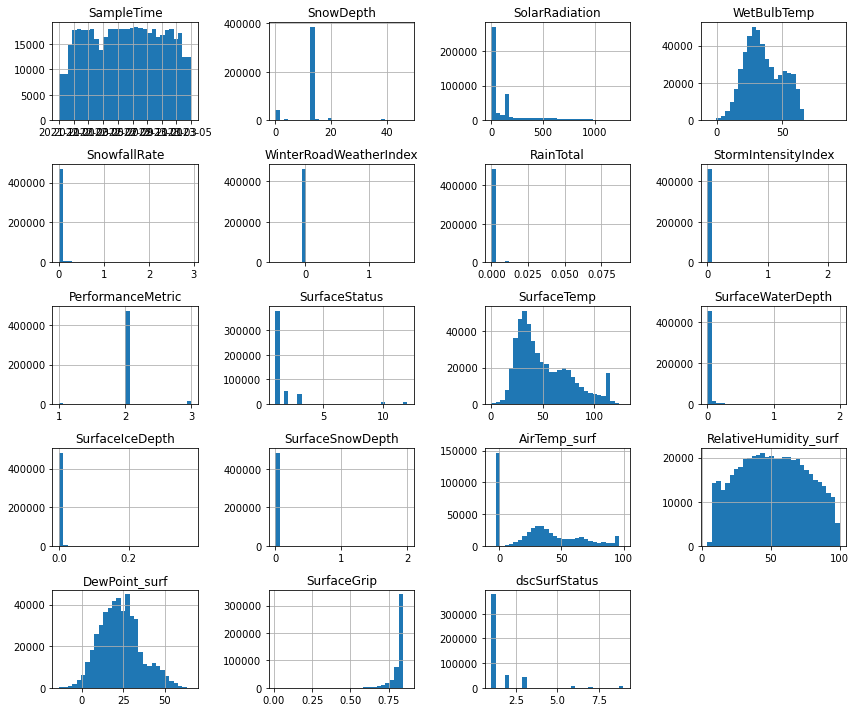

In [4]:
# Cell 4: histograms for all numeric columns
import matplotlib.pyplot as plt
%matplotlib inline

df_merged_1.hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

## make sure time_diff is the same

In [5]:
df_merged_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492011 entries, 0 to 492010
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              492011 non-null  datetime64[ns]
 1   RwisControllerIntId     492011 non-null  object        
 2   PrecipitationIntensity  43029 non-null   object        
 3   SnowDepth               492011 non-null  float64       
 4   SolarRadiation          492011 non-null  float64       
 5   PrecipitationType       491376 non-null  object        
 6   WetBulbTemp             492011 non-null  float64       
 7   SnowfallRate            492011 non-null  float64       
 8   WinterRoadWeatherIndex  492011 non-null  float64       
 9   RainTotal               492011 non-null  float64       
 10  StormIntensityIndex     492011 non-null  float64       
 11  PerformanceMetric       492011 non-null  float64       
 12  SurfaceStatus           492011

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# === 1. Load & Prepare Data (assuming already merged into df_merged) ===
# We assume df_merged is available in the environment.

# Sort and compute time differences
df = df_merged_1.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
df['time_diff'] = df.groupby('RwisControllerIntId')['SampleTime'].diff()

mask_drop5 = (
    (df['time_diff'] == pd.Timedelta(minutes=5)) &
    (df['SampleTime'].dt.minute % 10 == 5)
)

df2 = df[~mask_drop5].reset_index(drop=True)
df2 = df2.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
df2['time_diff'] = df2.groupby('RwisControllerIntId')['SampleTime'].diff()

df10 = df2[df2['time_diff'] == pd.Timedelta(minutes=10)].reset_index(drop=True)

# === 2. One-hot encoding of categorical columns ===
cat_cols = [
    'PrecipitationIntensity',
    'PrecipitationType',
#     'SurfaceStatusText',
#     'dscRoadStatusText'
]
df_encoded = pd.get_dummies(df10, columns=cat_cols)

# === 3. Define features and label ===
label_col = 'SurfaceGrip'
feature_cols = df_encoded.columns.drop(['SampleTime', 'RwisControllerIntId', 'time_diff', label_col]).tolist()


# === 4. Normalize features ===
scaler = MinMaxScaler()
df_encoded[feature_cols] = scaler.fit_transform(df_encoded[feature_cols])

# === 5. Construct dataset ===
def build_rnn_dataset(df, feature_cols, label_col='SurfaceGrip', window=10):
    """
    构建 RNN 用的数据：
    - 输入：前 window 步的 (X + y)，再加上当前步的 X 和 t-1 的 y
    - 输出：当前步的 y
    """
    X_seq, y_seq = [], []
    df = df.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)

    grouped = df.groupby('RwisControllerIntId')
    for _, group in grouped:
        group = group.reset_index(drop=True)
        for i in range(window, len(group)):
            hist = group.iloc[i - window:i]
            target = group.iloc[i]

            hist_features = hist[feature_cols].values          # shape: (window, F)
            hist_labels = hist[[label_col]].values             # shape: (window, 1)
            hist_combined = np.hstack([hist_features, hist_labels])  # shape: (window, F+1)

            curr_features = target[feature_cols].values.reshape(1, -1)  # shape: (1, F)
            prev_y = hist_labels[-1:]  # shape: (1, 1), 即 t-1 的 y
            curr_combined = np.hstack([curr_features, prev_y])         # shape: (1, F+1)

            seq = np.vstack([hist_combined, curr_combined])    # shape: (window + 1, F+1)
            X_seq.append(seq)
            y_seq.append(target[label_col])

    return np.array(X_seq), np.array(y_seq)



def build_tabular_dataset(df, feature_cols, label_col='SurfaceGrip', window=10):
    X_tab = []
    y_tab = []

    grouped = df.sort_values(['RwisControllerIntId', 'SampleTime']).groupby('RwisControllerIntId')
    for _, group in grouped:
        group = group.reset_index(drop=True)
        for i in range(window, len(group)):
            target = group.iloc[i]
            X_tab.append(target[feature_cols].values)
            y_tab.append(target[label_col])
    return np.array(X_tab), np.array(y_tab)


X_seq, y = build_rnn_dataset(df_encoded, feature_cols, label_col='SurfaceGrip', window=10)
X_tab, _ = build_tabular_dataset(df_encoded, feature_cols, label_col='SurfaceGrip', window=10)

# # === 6. Train-test split ===
# X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
#     X_seq, X_tab, y, test_size=0.2, random_state=42
# )

# === 7. Evaluation function ===
def evaluate_model(y_true, y_pred, bins=np.arange(0.0, 1.01, 0.1)):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    metrics = pd.DataFrame({
        'Metric': ['MSE','MAE','MAPE','R2'],
        'Value': [mse, mae, mape, r2]
    }).set_index('Metric')
    print("Overall Metrics:")
    display(metrics.style.format({'Value':'{:.4f}'}))

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn,mx],[mn,mx],'r--', linewidth=1)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title('True vs Predicted')
    plt.tight_layout()
    plt.show()

    labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins, labels=labels, include_lowest=True)

    seg_results = []
    for lbl in labels:
        sub = df_eval[df_eval['bin'] == lbl]
        count = len(sub)
        seg_r2 = r2_score(sub['y_true'], sub['y_pred']) if count >= 2 else np.nan
        seg_results.append({'Interval': lbl, 'Count': count, 'R2': seg_r2})

    seg_df = pd.DataFrame(seg_results).set_index('Interval')
    avg_r2 = seg_df['R2'].mean(skipna=True)

    print("\nSegmented R² by True-Value Bin:")
    display(seg_df.style.format({'Count':'{:.0f}','R2':'{:.4f}'}))
    print(f"Average segmented R²: {avg_r2:.4f}")

    fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, lbl in zip(axes, labels):
        sub = df_eval[df_eval['bin'] == lbl]
        ax.scatter(sub['y_true'], sub['y_pred'], alpha=0.5, s=10)
        ax.plot([0,1],[0,1],'r--', linewidth=1)
        ax.set_title(lbl)
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.set_xlabel('True')
        ax.set_ylabel('Pred')
    for ax in axes[len(labels):]:
        ax.axis('off')
    plt.suptitle('Segmented True vs Pred by Bin', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# return final dataset shapes for confirmation
X_seq.shape, X_tab.shape, y.shape




((276848, 11, 24), (276848, 23), (276848,))

## generate train and test data for time-series model and machine learning model

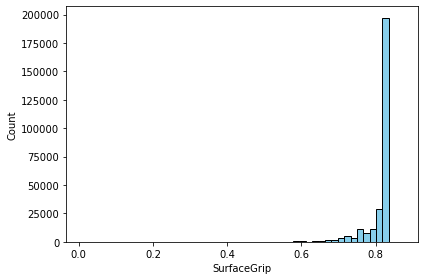

In [23]:
# === 分布可视化（清洗前） ===
plt.figure()
plt.hist(y, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("SurfaceGrip")
plt.ylabel("Count")
# plt.title("Histogram of SurfaceGrip before balancing")
plt.tight_layout()
# plt.tight_layout()
plt.savefig('before balance.png', dpi=600)

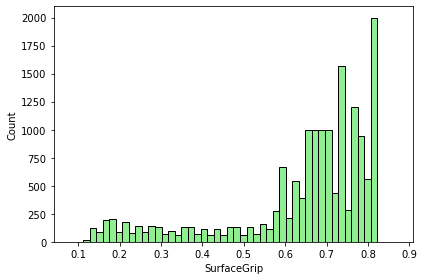

In [25]:
# === 分布可视化（均衡后） ===
plt.figure()
plt.hist(y_bal, bins=50, color='lightgreen', edgecolor='black')
plt.xlabel("SurfaceGrip")
plt.ylabel("Count")
# plt.title("Histogram of SurfaceGrip after balancing")
plt.tight_layout()
plt.savefig('after balance.png', dpi=600)

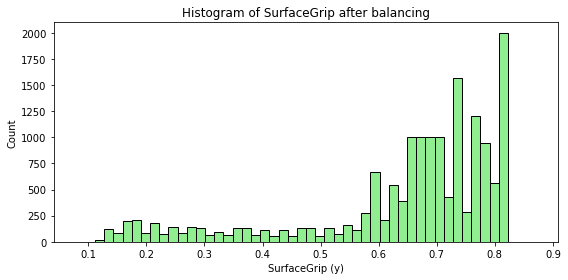

X_seq: (13004, 11, 24) X_tab: (13004, 23) y: (13004,)


In [8]:
def balance_y_distribution(X_seq, X_tab, y, bins=50, max_per_bin=1000, random_state=44):
    np.random.seed(random_state)
    bin_edges = np.linspace(np.min(y), np.max(y), bins + 1)
    bin_indices = np.digitize(y, bins=bin_edges, right=True)

    selected_indices = []
    for b in range(1, bins + 1):
        bin_mask = bin_indices == b
        idx_in_bin = np.where(bin_mask)[0]
        if len(idx_in_bin) > max_per_bin:
            idx_selected = np.random.choice(idx_in_bin, size=max_per_bin, replace=False)
        else:
            idx_selected = idx_in_bin
        selected_indices.extend(idx_selected)

    selected_indices = np.array(selected_indices)
    return (
        X_seq[selected_indices],
        X_tab[selected_indices],
        y[selected_indices]
    )

# === 应用均衡 ===
X_seq_bal, X_tab_bal, y_bal = balance_y_distribution(X_seq, X_tab, y, bins=50, max_per_bin=1000)

# === 分布可视化（均衡后） ===
plt.figure(figsize=(8, 4))
plt.hist(y_bal, bins=50, color='lightgreen', edgecolor='black')
plt.xlabel("SurfaceGrip (y)")
plt.ylabel("Count")
plt.title("Histogram of SurfaceGrip after balancing")
plt.tight_layout()
plt.show()

# === Train-test split ===
X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_seq_bal, X_tab_bal, y_bal, test_size=0.2, random_state=44
)

# 最终维度确认
print("X_seq:", X_seq_train.shape, "X_tab:", X_tab_train.shape, "y:", y_train.shape)


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, bins=np.arange(0.0, 1.01, 0.1)):
    # === Overall metrics ===
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    metrics = pd.DataFrame({
        'Metric': ['MSE','MAE','MAPE','R2'],
        'Value': [mse, mae, mape, r2]
    }).set_index('Metric')
    print("Overall Metrics:")
    display(metrics.style.format({'Value':'{:.4f}'}))

    # === Scatter Plot ===
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn,mx],[mn,mx],'r--', linewidth=1)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title('True vs Predicted')
    plt.tight_layout()
    plt.show()

    # === Segmented Evaluation ===
    labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins, labels=labels, include_lowest=True)

    seg_results = []
    for lbl in labels:
        sub = df_eval[df_eval['bin'] == lbl]
        count = len(sub)
        if count >= 2:
            r2_val   = r2_score(sub['y_true'], sub['y_pred'])
            mse_val  = mean_squared_error(sub['y_true'], sub['y_pred'])
            mae_val  = mean_absolute_error(sub['y_true'], sub['y_pred'])
            mape_val = mean_absolute_percentage_error(sub['y_true'], sub['y_pred'])
        else:
            r2_val = mse_val = mae_val = mape_val = np.nan
        seg_results.append({
            'Interval': lbl, 'Count': count,
            'R2': r2_val, 'MSE': mse_val,
            'MAE': mae_val, 'MAPE': mape_val
        })

    seg_df = pd.DataFrame(seg_results).set_index('Interval')
    print("\nSegmented Metrics by True-Value Bin:")
    display(seg_df.style.format({'Count': '{:.0f}', 'R2': '{:.4f}', 'MSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.4f}'}))

    print(f"\nAverage Segmented Metrics (skip NaN):")
    print(f"  R2:   {seg_df['R2'].mean(skipna=True):.4f}")
    print(f"  MSE:  {seg_df['MSE'].mean(skipna=True):.4f}")
    print(f"  MAE:  {seg_df['MAE'].mean(skipna=True):.4f}")
    print(f"  MAPE: {seg_df['MAPE'].mean(skipna=True):.4f}")

    # === Segment Scatter Plots ===
    fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, lbl in zip(axes, labels):
        sub = df_eval[df_eval['bin'] == lbl]
        ax.scatter(sub['y_true'], sub['y_pred'], alpha=0.5, s=10)
        ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
        ax.set_title(lbl)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('True')
        ax.set_ylabel('Pred')
    for ax in axes[len(labels):]:
        ax.axis('off')
    plt.suptitle('Segmented True vs Pred by Bin', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()



--- RandomForest ---
Overall Metrics:


,Value
Metric,
MSE,0.0053
MAE,0.0558
MAPE,0.1363
R2,0.8269


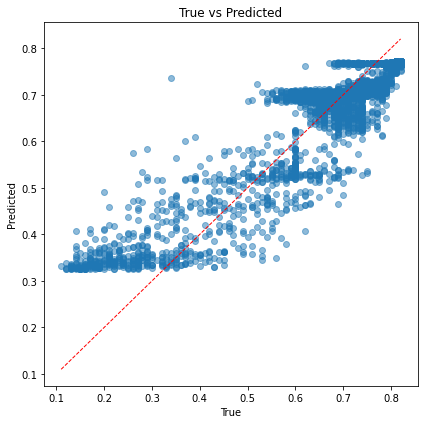


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-73.6965,0.0324,0.1783,1.1456
0.2-0.3,169,-18.0909,0.0169,0.1200,0.5039
0.3-0.4,121,-10.7491,0.0086,0.0665,0.1932
0.4-0.5,120,-4.1686,0.0047,0.0581,0.1297
0.5-0.6,181,-12.9166,0.0090,0.0803,0.1439
0.6-0.7,1006,-2.3112,0.0033,0.0449,0.0696
0.7-0.8,1046,-3.5331,0.0026,0.0408,0.0544
0.8-0.9,487,-34.9662,0.0022,0.0455,0.0561



Average Segmented Metrics (skip NaN):
  R2:   -20.0540
  MSE:  0.0100
  MAE:  0.0793
  MAPE: 0.2870


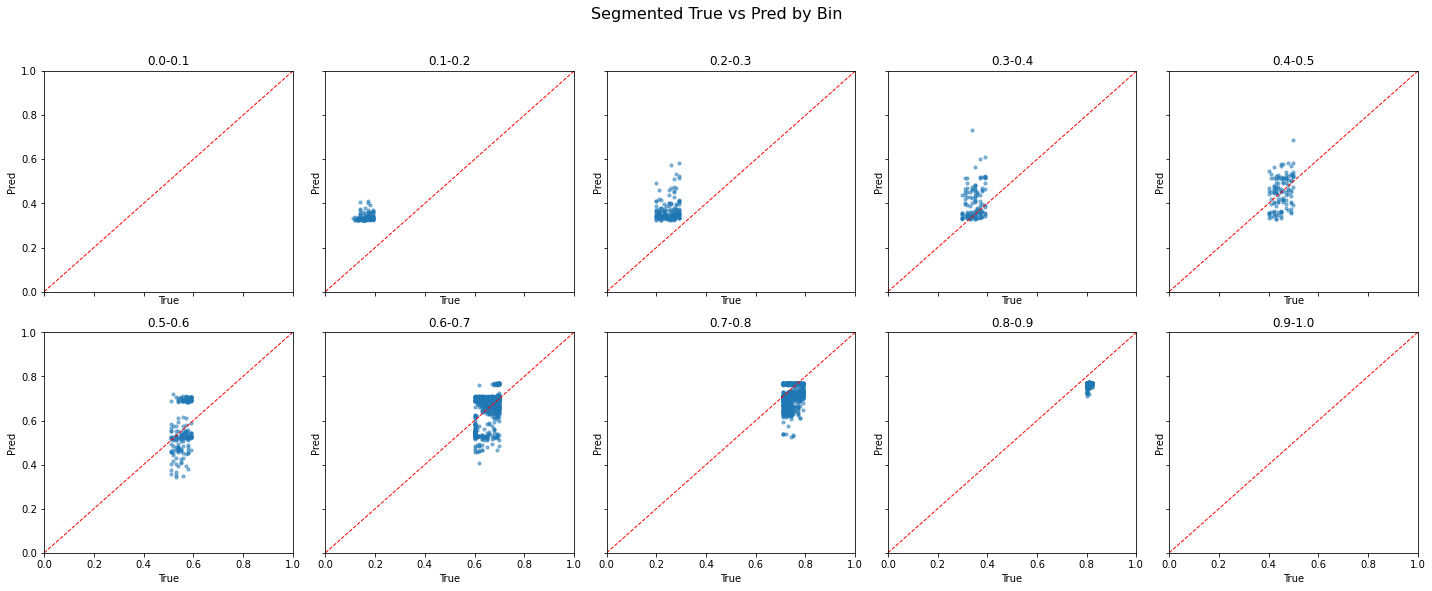


--- DecisionTree ---
Overall Metrics:


,Value
Metric,
MSE,0.0111
MAE,0.0733
MAPE,0.1808
R2,0.6371


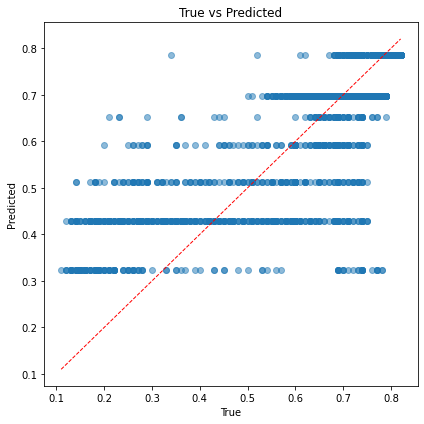


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-116.7857,0.0511,0.2177,1.3870
0.2-0.3,169,-46.0931,0.0418,0.1893,0.7839
0.3-0.4,121,-20.0774,0.0154,0.1056,0.3103
0.4-0.5,120,-5.8227,0.0062,0.0582,0.1293
0.5-0.6,181,-19.3505,0.0132,0.1035,0.1853
0.6-0.7,1006,-6.7791,0.0078,0.0615,0.0952
0.7-0.8,1046,-14.7343,0.0091,0.0643,0.0860
0.8-0.9,487,-10.5084,0.0007,0.0251,0.0308



Average Segmented Metrics (skip NaN):
  R2:   -30.0189
  MSE:  0.0181
  MAE:  0.1032
  MAPE: 0.3760


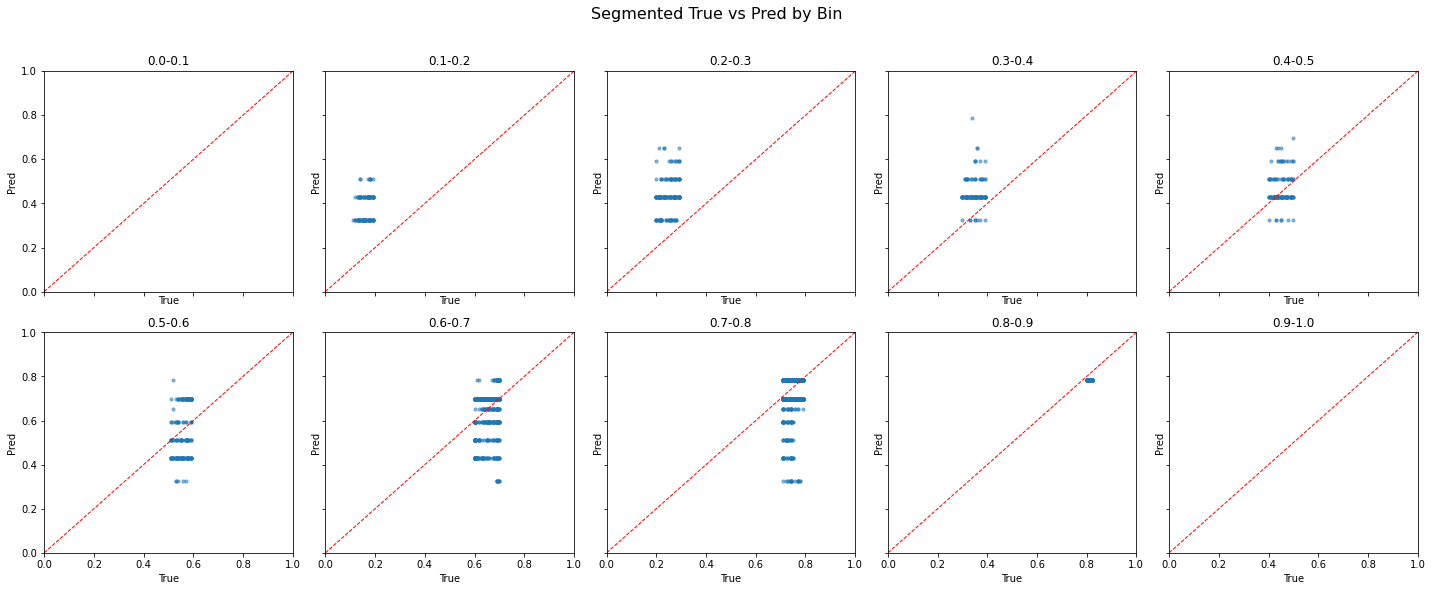


--- XGBoost ---
Overall Metrics:


,Value
Metric,
MSE,0.0015
MAE,0.0256
MAPE,0.0573
R2,0.9516


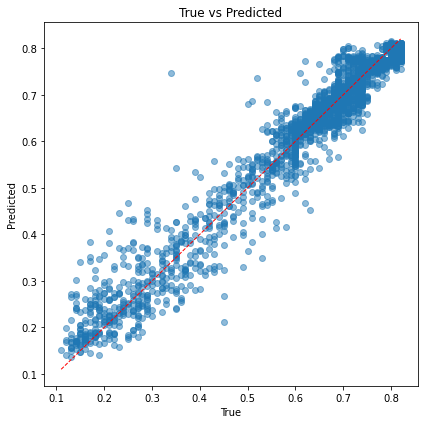


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-9.9072,0.0047,0.0513,0.3268
0.2-0.3,169,-4.2082,0.0046,0.0496,0.2025
0.3-0.4,121,-5.0686,0.0044,0.0473,0.1359
0.4-0.5,120,-3.4119,0.0040,0.0478,0.1069
0.5-0.6,181,-3.5921,0.0030,0.0406,0.0736
0.6-0.7,1006,0.0380,0.0010,0.0218,0.0333
0.7-0.8,1046,-0.1257,0.0007,0.0184,0.0248
0.8-0.9,487,-7.0470,0.0005,0.0176,0.0217



Average Segmented Metrics (skip NaN):
  R2:   -4.1653
  MSE:  0.0029
  MAE:  0.0368
  MAPE: 0.1157


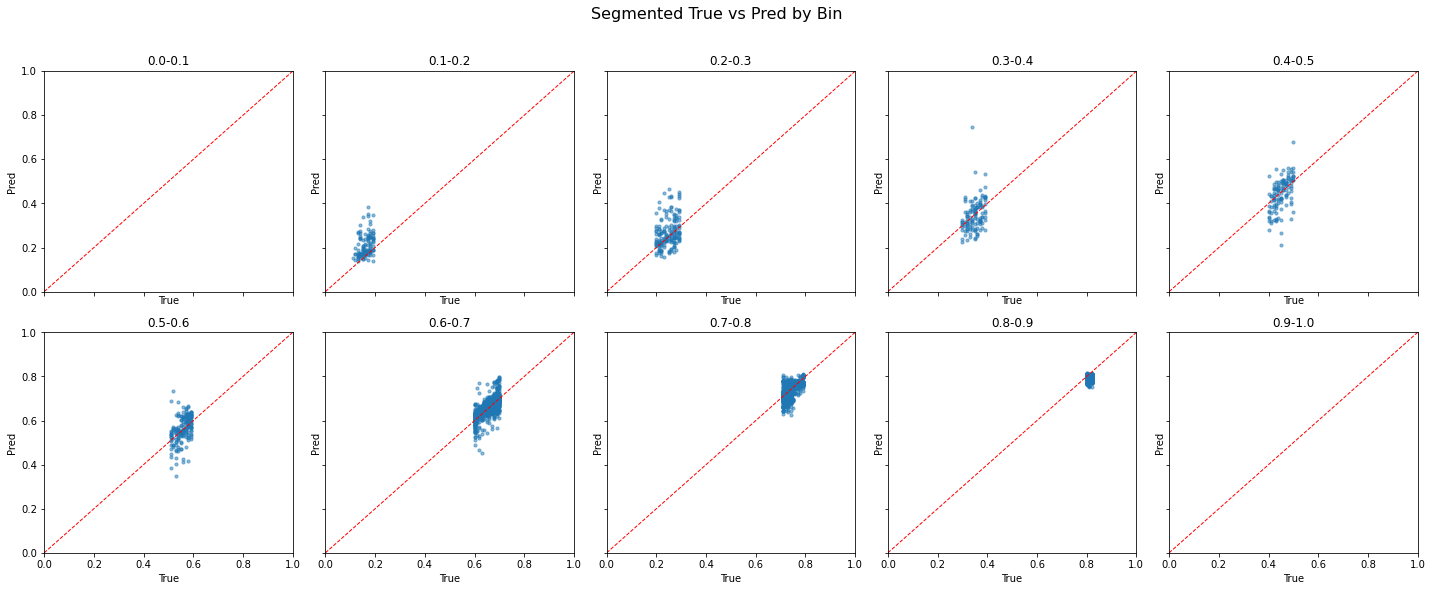


--- ANN (MLP) ---
Overall Metrics:


,Value
Metric,
MSE,0.0022
MAE,0.0298
MAPE,0.0688
R2,0.9286


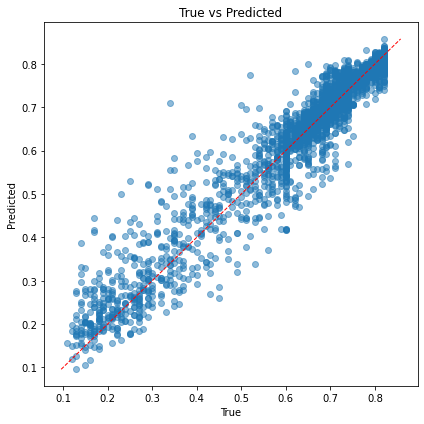


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-15.5481,0.0072,0.0638,0.4077
0.2-0.3,169,-6.0912,0.0063,0.0558,0.2302
0.3-0.4,121,-10.2037,0.0082,0.0679,0.1951
0.4-0.5,120,-6.1531,0.0065,0.0636,0.1417
0.5-0.6,181,-5.5029,0.0042,0.0498,0.0901
0.6-0.7,1006,-0.6562,0.0017,0.0284,0.0436
0.7-0.8,1046,-0.2275,0.0007,0.0185,0.0250
0.8-0.9,487,-5.8817,0.0004,0.0145,0.0178



Average Segmented Metrics (skip NaN):
  R2:   -6.2831
  MSE:  0.0044
  MAE:  0.0453
  MAPE: 0.1439


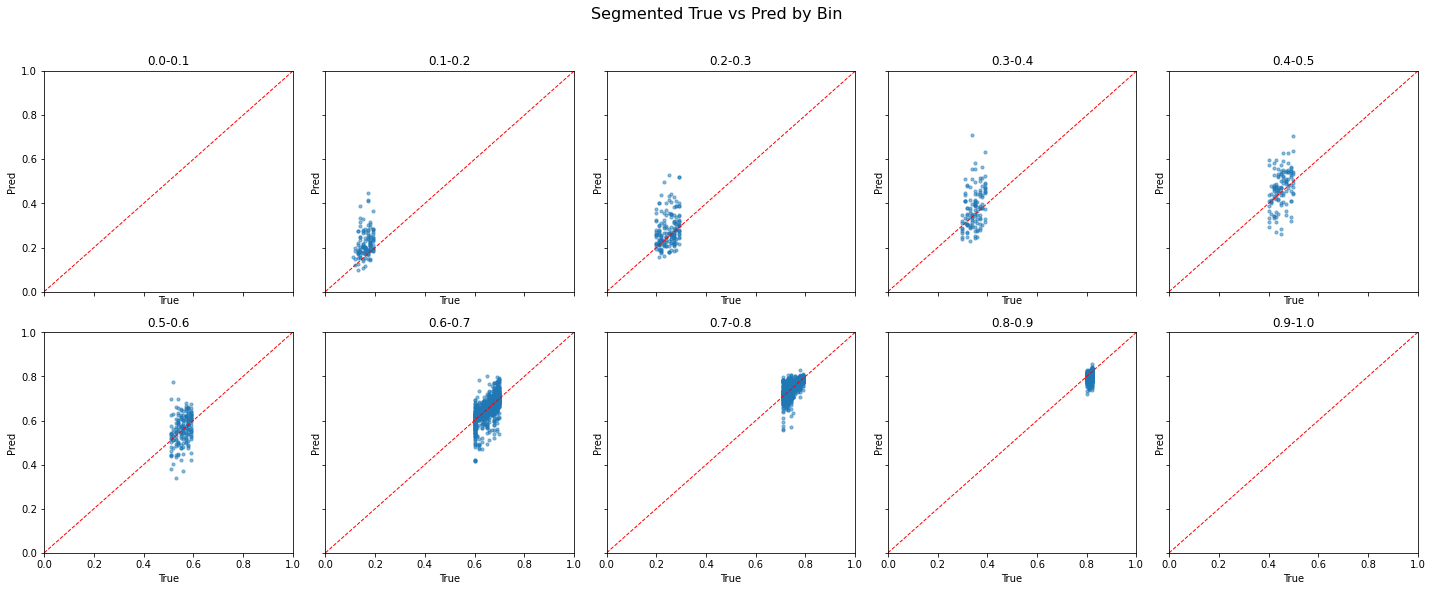

In [10]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# 假定 X_seq, X_tab, y, evaluate_model 都已在环境中定义好，且 df10 已无 NaN

# # 1）统一划分训练/测试集（RNN 和 Tabular 都用相同的 split）
# X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
#     X_seq, X_tab, y, test_size=0.2, random_state=42
# )

# 2）定义并训练四个 Tabular 模型
tab_models = {
    'RandomForest': RandomForestRegressor(    n_estimators=100,
    max_depth=3,                 # limit depth
    min_samples_split=20,   
    min_samples_leaf=10,  
    max_features='sqrt',    
    random_state=44),
    'DecisionTree': DecisionTreeRegressor( 
        max_depth=3,       
    min_samples_split=20,     
    min_samples_leaf=10,    
    max_features='sqrt',  
    random_state=44),
    'XGBoost':      XGBRegressor(    n_estimators=200,
    learning_rate=0.1,         
    max_depth=2,        
    subsample=0.8,  
    colsample_bytree=0.7,    
    min_child_weight=10,    
    reg_alpha=1,  
    reg_lambda=5,
    objective='reg:squarederror',
    random_state=44),
    'ANN (MLP)':    MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                                 solver='adam', max_iter=200, random_state=44)
}

for name, model in tab_models.items():
    print(f"\n--- {name} ---")
    # 直接用 X_tab_train, y_train，因为已经无 NaN
    model.fit(X_tab_train, y_train)
    y_pred = model.predict(X_tab_test)
    evaluate_model(y_test, y_pred)




--- Simple RNN ---
Epoch 1/200
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 6s - loss: 0.0270 - 6s/epoch - 15ms/step
Epoch 2/200
407/407 - 1s - loss: 0.0047 - 1s/epoch - 3ms/step
Epoch 3/200
407/407 - 1s - loss: 0.0037 - 1s/epoch - 3ms/step
Epoch 4/200
407/407 - 1s - loss: 0.0033 - 1s/epoch - 3ms/step
Epoch 5/200
407/407 - 1s - loss: 0.0033 - 948ms/epoch - 2ms/step
Epoch 6/200
407/407 - 1s - loss: 0.0031 - 88

Epoch 112/200
407/407 - 1s - loss: 7.1373e-04 - 833ms/epoch - 2ms/step
Epoch 113/200
407/407 - 1s - loss: 6.8546e-04 - 804ms/epoch - 2ms/step
Epoch 114/200
407/407 - 1s - loss: 7.0048e-04 - 793ms/epoch - 2ms/step
Epoch 115/200
407/407 - 1s - loss: 7.0692e-04 - 766ms/epoch - 2ms/step
Epoch 116/200
407/407 - 1s - loss: 6.5940e-04 - 822ms/epoch - 2ms/step
Epoch 117/200
407/407 - 1s - loss: 7.2343e-04 - 849ms/epoch - 2ms/step
Epoch 118/200
407/407 - 1s - loss: 6.7880e-04 - 863ms/epoch - 2ms/step
Epoch 119/200
407/407 - 1s - loss: 6.6426e-04 - 935ms/epoch - 2ms/step
Epoch 120/200
407/407 - 1s - loss: 6.8512e-04 - 914ms/epoch - 2ms/step
Epoch 121/200
407/407 - 1s - loss: 6.4124e-04 - 813ms/epoch - 2ms/step
Epoch 122/200
407/407 - 1s - loss: 6.6575e-04 - 762ms/epoch - 2ms/step
Epoch 123/200
407/407 - 1s - loss: 6.5886e-04 - 833ms/epoch - 2ms/step
Epoch 124/200
407/407 - 1s - loss: 6.3742e-04 - 780ms/epoch - 2ms/step
Epoch 125/200
407/407 - 1s - loss: 5.9827e-04 - 750ms/epoch - 2ms/step
Epoch 

,Value
Metric,
MSE,0.0012
MAE,0.0193
MAPE,0.0466
R2,0.9608


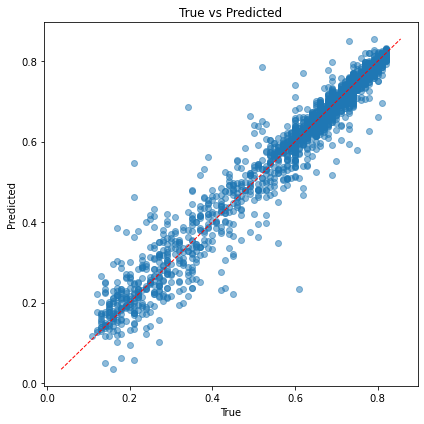


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-6.2768,0.0032,0.0396,0.2497
0.2-0.3,169,-4.4527,0.0048,0.0494,0.2035
0.3-0.4,121,-5.5073,0.0047,0.0521,0.1507
0.4-0.5,120,-3.4397,0.0040,0.0454,0.1014
0.5-0.6,181,-2.8267,0.0025,0.0344,0.0628
0.6-0.7,1006,0.2469,0.0008,0.0162,0.0250
0.7-0.8,1046,0.4228,0.0003,0.0114,0.0152
0.8-0.9,487,-1.4948,0.0001,0.0070,0.0086



Average Segmented Metrics (skip NaN):
  R2:   -2.9160
  MSE:  0.0026
  MAE:  0.0319
  MAPE: 0.1021


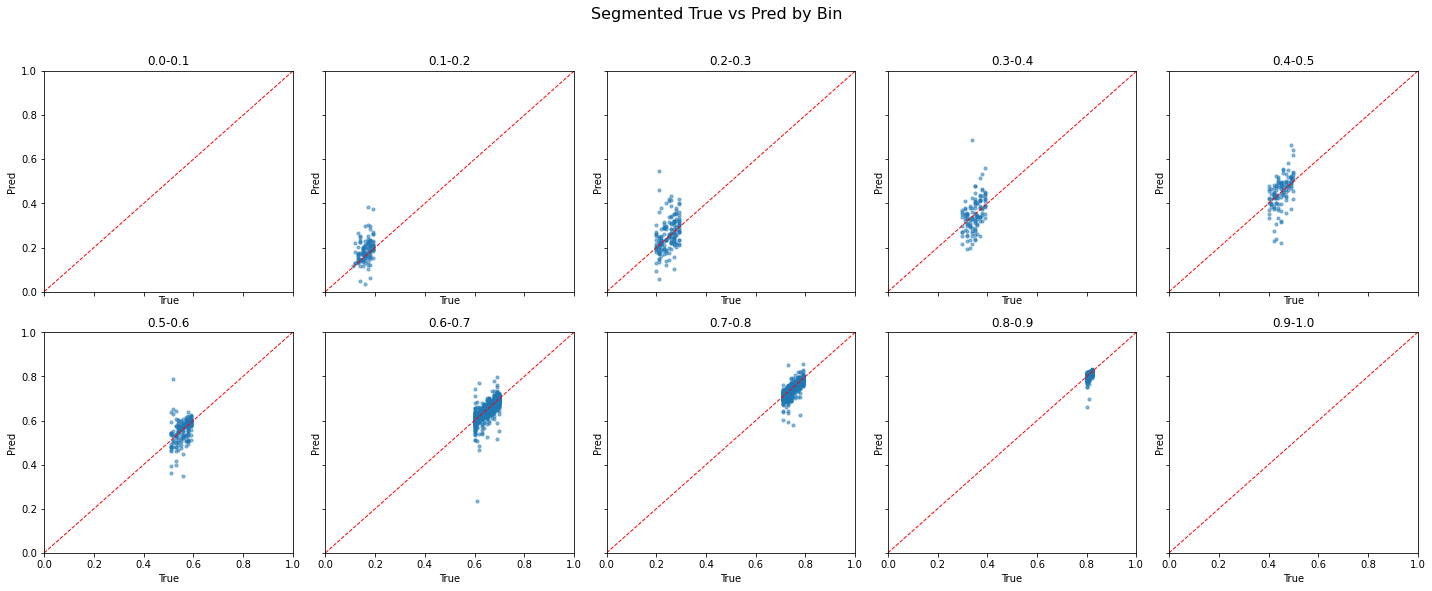


--- LSTM ---
Epoch 1/200
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 8s - loss: 0.0089 - 8s/epoch - 19ms/step
Epoch 2/200
407/407 - 2s - loss: 0.0036 - 2s/epoch - 4ms/step
Epoch 3/200
407/407 - 2s - loss: 0.0028 - 2s/epoch - 4ms/step
Epoch 4/200
407/407 - 2s - loss: 0.0026 - 2s/epoch - 4ms/step
Epoch 5/200
407/407 - 2s - loss: 0.0025 - 2s/epoch - 4ms/step
Epoch 6/200
407/407 - 2s - loss: 0.0023 - 2s/epoch - 

Epoch 112/200
407/407 - 1s - loss: 3.3684e-04 - 1s/epoch - 3ms/step
Epoch 113/200
407/407 - 1s - loss: 3.2900e-04 - 1s/epoch - 4ms/step
Epoch 114/200
407/407 - 2s - loss: 3.3054e-04 - 2s/epoch - 4ms/step
Epoch 115/200
407/407 - 2s - loss: 3.2197e-04 - 2s/epoch - 4ms/step
Epoch 116/200
407/407 - 2s - loss: 3.3328e-04 - 2s/epoch - 4ms/step
Epoch 117/200
407/407 - 2s - loss: 3.1559e-04 - 2s/epoch - 4ms/step
Epoch 118/200
407/407 - 2s - loss: 3.3324e-04 - 2s/epoch - 4ms/step
Epoch 119/200
407/407 - 2s - loss: 3.1036e-04 - 2s/epoch - 4ms/step
Epoch 120/200
407/407 - 1s - loss: 3.0402e-04 - 1s/epoch - 4ms/step
Epoch 121/200
407/407 - 1s - loss: 2.9027e-04 - 1s/epoch - 4ms/step
Epoch 122/200
407/407 - 2s - loss: 3.0970e-04 - 2s/epoch - 4ms/step
Epoch 123/200
407/407 - 1s - loss: 2.8860e-04 - 1s/epoch - 4ms/step
Epoch 124/200
407/407 - 1s - loss: 2.8942e-04 - 1s/epoch - 4ms/step
Epoch 125/200
407/407 - 1s - loss: 2.8226e-04 - 1s/epoch - 4ms/step
Epoch 126/200
407/407 - 2s - loss: 2.7920e-04 - 

,Value
Metric,
MSE,0.0012
MAE,0.0191
MAPE,0.0466
R2,0.9593


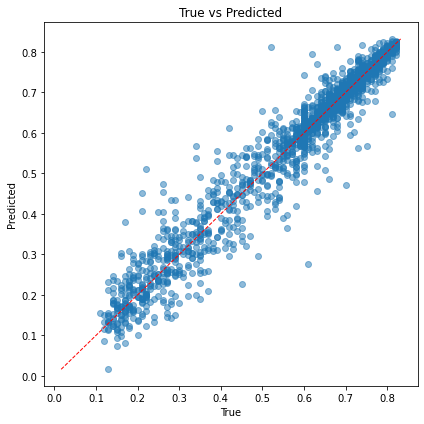


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-5.3650,0.0028,0.0392,0.2458
0.2-0.3,169,-4.4529,0.0048,0.0504,0.2056
0.3-0.4,121,-5.1257,0.0045,0.0512,0.1468
0.4-0.5,120,-3.9533,0.0045,0.0508,0.1136
0.5-0.6,181,-3.8650,0.0032,0.0392,0.0715
0.6-0.7,1006,0.1629,0.0008,0.0165,0.0254
0.7-0.8,1046,0.4428,0.0003,0.0103,0.0139
0.8-0.9,487,-0.7507,0.0001,0.0044,0.0054



Average Segmented Metrics (skip NaN):
  R2:   -2.8633
  MSE:  0.0026
  MAE:  0.0327
  MAPE: 0.1035


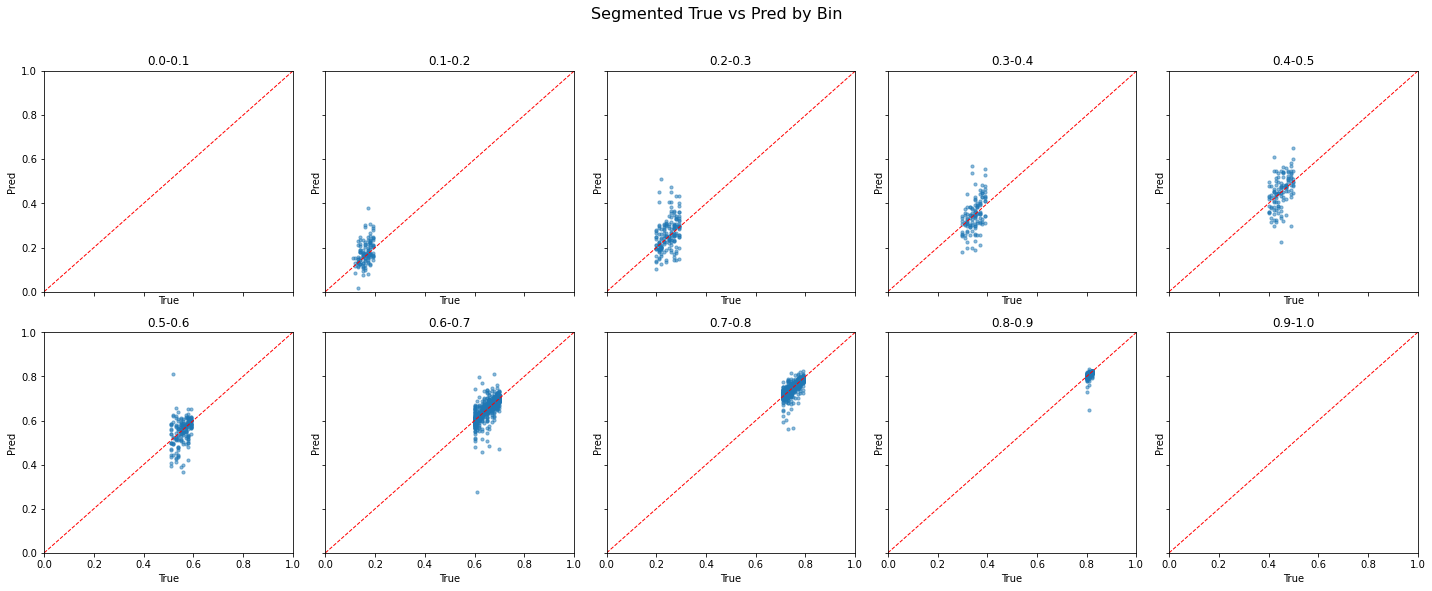

In [26]:
# 3）训练并评估 Simple RNN
# Ensure dtype
X_seq_train = X_seq_train.astype(np.float32)
X_seq_test  = X_seq_test.astype(np.float32)
y_train     = y_train.astype(np.float32)
y_test      = y_test.astype(np.float32)
print("\n--- Simple RNN ---")
model_rnn = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, 
        input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    tf.keras.layers.Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(
    X_seq_train, y_train,
    epochs=200, batch_size=32,
     verbose=2
)
y_pred_rnn = model_rnn.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_rnn)

# 4）训练并评估 LSTM
print("\n--- LSTM ---")
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, 
        input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    tf.keras.layers.Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(
    X_seq_train, y_train,
    epochs=200, batch_size=32,
     verbose=2
)
y_pred_lstm = model_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_lstm)



--- Stacked LSTM with Dropout & Normalization ---
Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 7s - loss: 0.0251 - 7s/epoch - 17ms/step
Epoch 2/600
407/407 - 3s - loss: 0.0116 - 3s/epoch - 7ms/step
Epoch 3/600
407/407 - 3s - loss: 0.0086 - 3s/epoch - 7ms/step
Epoch 4/600
407/407 - 3s - loss: 0.0067 - 3s/epoch - 7ms/step
Epoch 5/600
407/407 - 3s - loss: 0.0056 - 3s/epoch - 7ms/step
Epoch 6/600
407/

Epoch 115/600
407/407 - 3s - loss: 8.8198e-04 - 3s/epoch - 8ms/step
Epoch 116/600
407/407 - 4s - loss: 8.7802e-04 - 4s/epoch - 9ms/step
Epoch 117/600
407/407 - 4s - loss: 8.9016e-04 - 4s/epoch - 9ms/step
Epoch 118/600
407/407 - 3s - loss: 8.9912e-04 - 3s/epoch - 8ms/step
Epoch 119/600
407/407 - 3s - loss: 8.8205e-04 - 3s/epoch - 8ms/step
Epoch 120/600
407/407 - 3s - loss: 8.6569e-04 - 3s/epoch - 8ms/step
Epoch 121/600
407/407 - 3s - loss: 8.8301e-04 - 3s/epoch - 8ms/step
Epoch 122/600
407/407 - 3s - loss: 8.8002e-04 - 3s/epoch - 8ms/step
Epoch 123/600
407/407 - 3s - loss: 8.8043e-04 - 3s/epoch - 8ms/step
Epoch 124/600
407/407 - 3s - loss: 8.9217e-04 - 3s/epoch - 8ms/step
Epoch 125/600
407/407 - 3s - loss: 8.4387e-04 - 3s/epoch - 8ms/step
Epoch 126/600
407/407 - 3s - loss: 8.5340e-04 - 3s/epoch - 8ms/step
Epoch 127/600
407/407 - 4s - loss: 8.8207e-04 - 4s/epoch - 9ms/step
Epoch 128/600
407/407 - 3s - loss: 8.6271e-04 - 3s/epoch - 8ms/step
Epoch 129/600
407/407 - 3s - loss: 8.5623e-04 - 

Epoch 236/600
407/407 - 3s - loss: 6.8627e-04 - 3s/epoch - 8ms/step
Epoch 237/600
407/407 - 3s - loss: 6.4860e-04 - 3s/epoch - 8ms/step
Epoch 238/600
407/407 - 3s - loss: 6.3119e-04 - 3s/epoch - 8ms/step
Epoch 239/600
407/407 - 3s - loss: 6.5122e-04 - 3s/epoch - 8ms/step
Epoch 240/600
407/407 - 3s - loss: 6.3622e-04 - 3s/epoch - 8ms/step
Epoch 241/600
407/407 - 3s - loss: 6.5224e-04 - 3s/epoch - 8ms/step
Epoch 242/600
407/407 - 3s - loss: 6.2990e-04 - 3s/epoch - 8ms/step
Epoch 243/600
407/407 - 4s - loss: 6.5436e-04 - 4s/epoch - 9ms/step
Epoch 244/600
407/407 - 3s - loss: 6.3555e-04 - 3s/epoch - 8ms/step
Epoch 245/600
407/407 - 3s - loss: 6.5078e-04 - 3s/epoch - 8ms/step
Epoch 246/600
407/407 - 3s - loss: 6.3590e-04 - 3s/epoch - 8ms/step
Epoch 247/600
407/407 - 3s - loss: 6.7492e-04 - 3s/epoch - 8ms/step
Epoch 248/600
407/407 - 3s - loss: 6.3989e-04 - 3s/epoch - 8ms/step
Epoch 249/600
407/407 - 3s - loss: 6.3789e-04 - 3s/epoch - 8ms/step
Epoch 250/600
407/407 - 3s - loss: 6.1726e-04 - 

Epoch 357/600
407/407 - 3s - loss: 5.5399e-04 - 3s/epoch - 7ms/step
Epoch 358/600
407/407 - 3s - loss: 5.4295e-04 - 3s/epoch - 7ms/step
Epoch 359/600
407/407 - 3s - loss: 5.5004e-04 - 3s/epoch - 7ms/step
Epoch 360/600
407/407 - 3s - loss: 5.5620e-04 - 3s/epoch - 7ms/step
Epoch 361/600
407/407 - 3s - loss: 5.7376e-04 - 3s/epoch - 7ms/step
Epoch 362/600
407/407 - 3s - loss: 5.7303e-04 - 3s/epoch - 7ms/step
Epoch 363/600
407/407 - 3s - loss: 5.9684e-04 - 3s/epoch - 7ms/step
Epoch 364/600
407/407 - 3s - loss: 5.6039e-04 - 3s/epoch - 7ms/step
Epoch 365/600
407/407 - 3s - loss: 5.5316e-04 - 3s/epoch - 7ms/step
Epoch 366/600
407/407 - 3s - loss: 5.5553e-04 - 3s/epoch - 8ms/step
Epoch 367/600
407/407 - 3s - loss: 5.5457e-04 - 3s/epoch - 7ms/step
Epoch 368/600
407/407 - 3s - loss: 5.5824e-04 - 3s/epoch - 8ms/step
Epoch 369/600
407/407 - 4s - loss: 5.5126e-04 - 4s/epoch - 10ms/step
Epoch 370/600
407/407 - 3s - loss: 5.7655e-04 - 3s/epoch - 7ms/step
Epoch 371/600
407/407 - 3s - loss: 5.4895e-04 -

Epoch 478/600
407/407 - 3s - loss: 5.0995e-04 - 3s/epoch - 7ms/step
Epoch 479/600
407/407 - 3s - loss: 5.2903e-04 - 3s/epoch - 7ms/step
Epoch 480/600
407/407 - 3s - loss: 5.0088e-04 - 3s/epoch - 7ms/step
Epoch 481/600
407/407 - 3s - loss: 4.9990e-04 - 3s/epoch - 7ms/step
Epoch 482/600
407/407 - 3s - loss: 5.1376e-04 - 3s/epoch - 7ms/step
Epoch 483/600
407/407 - 3s - loss: 5.0367e-04 - 3s/epoch - 7ms/step
Epoch 484/600
407/407 - 3s - loss: 4.9787e-04 - 3s/epoch - 7ms/step
Epoch 485/600
407/407 - 3s - loss: 4.9915e-04 - 3s/epoch - 7ms/step
Epoch 486/600
407/407 - 3s - loss: 4.8431e-04 - 3s/epoch - 7ms/step
Epoch 487/600
407/407 - 3s - loss: 5.0681e-04 - 3s/epoch - 7ms/step
Epoch 488/600
407/407 - 3s - loss: 5.1165e-04 - 3s/epoch - 7ms/step
Epoch 489/600
407/407 - 3s - loss: 4.8700e-04 - 3s/epoch - 7ms/step
Epoch 490/600
407/407 - 3s - loss: 5.0217e-04 - 3s/epoch - 7ms/step
Epoch 491/600
407/407 - 3s - loss: 5.0192e-04 - 3s/epoch - 7ms/step
Epoch 492/600
407/407 - 3s - loss: 5.1336e-04 - 

Epoch 599/600
407/407 - 3s - loss: 4.7415e-04 - 3s/epoch - 7ms/step
Epoch 600/600
407/407 - 3s - loss: 4.7219e-04 - 3s/epoch - 7ms/step
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
102/102 [==============================] - 2s 2ms/step
Overall Metrics:


,Value
Metric,
MSE,0.0009
MAE,0.0156
MAPE,0.0390
R2,0.9698


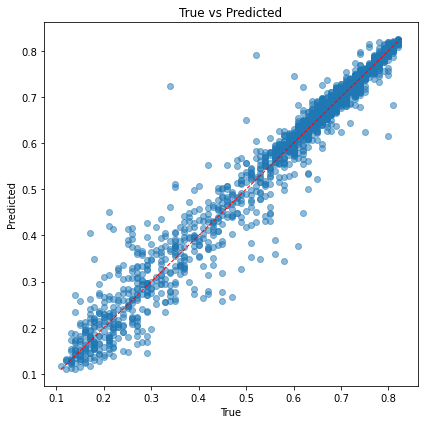


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-3.7704,0.0021,0.0311,0.1901
0.2-0.3,169,-3.7191,0.0042,0.0481,0.1970
0.3-0.4,121,-4.6715,0.0041,0.0461,0.1339
0.4-0.5,120,-3.0345,0.0036,0.0428,0.0956
0.5-0.6,181,-3.1009,0.0027,0.0326,0.0594
0.6-0.7,1006,0.5856,0.0004,0.0127,0.0195
0.7-0.8,1046,0.7807,0.0001,0.0072,0.0097
0.8-0.9,487,-1.2529,0.0001,0.0039,0.0048



Average Segmented Metrics (skip NaN):
  R2:   -2.2729
  MSE:  0.0022
  MAE:  0.0281
  MAPE: 0.0888


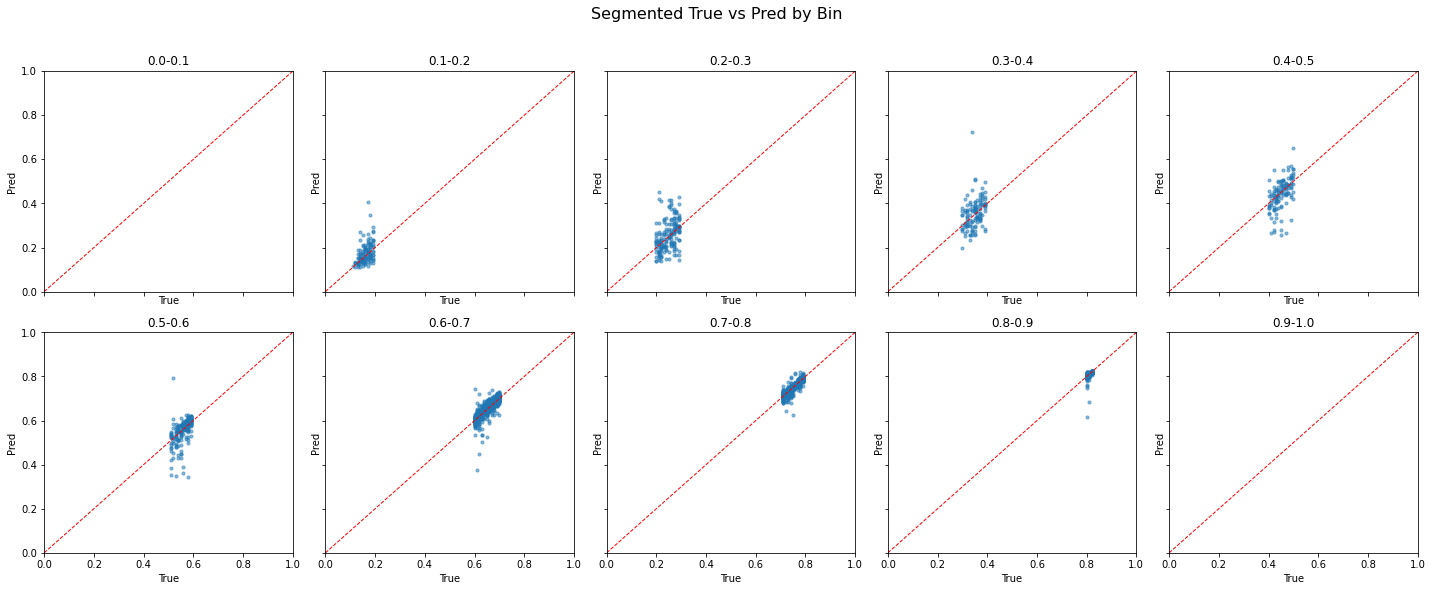

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, LayerNormalization, Dense

# 构建模型
model_stack_lstm = tf.keras.Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dropout(0.3),
    LayerNormalization(),

    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

# 编译模型
model_stack_lstm.compile(optimizer='adam', loss='mse')

# 添加 EarlyStopping（避免过拟合）
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 训练模型
print("\n--- Stacked LSTM with Dropout & Normalization ---")
model_stack_lstm.fit(
    X_seq_train, y_train,
    epochs=600, batch_size=32,
    verbose=2
)

# 预测与评估
y_pred_stack_lstm = model_stack_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_stack_lstm)


Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 6s - loss: 0.0128 - 6s/epoch - 14ms/step
Epoch 2/600
407/407 - 2s - loss: 0.0041 - 2s/epoch - 5ms/step
Epoch 3/600
407/407 - 2s - loss: 0.0033 - 2s/epoch - 5ms/step
Epoch 4/600
407/407 - 2s - loss: 0.0028 - 2s/epoch - 5ms/step
Epoch 5/600
407/407 - 2s - loss: 0.0027 - 2s/epoch - 4ms/step
Epoch 6/600
407/407 - 2s - loss: 0.0025 - 2s/epoch - 4ms/step
Epoch

Epoch 112/600
407/407 - 2s - loss: 2.8696e-04 - 2s/epoch - 4ms/step
Epoch 113/600
407/407 - 2s - loss: 2.8688e-04 - 2s/epoch - 5ms/step
Epoch 114/600
407/407 - 2s - loss: 3.1394e-04 - 2s/epoch - 4ms/step
Epoch 115/600
407/407 - 2s - loss: 2.8141e-04 - 2s/epoch - 4ms/step
Epoch 116/600
407/407 - 2s - loss: 2.7427e-04 - 2s/epoch - 4ms/step
Epoch 117/600
407/407 - 2s - loss: 2.6364e-04 - 2s/epoch - 4ms/step
Epoch 118/600
407/407 - 2s - loss: 2.6094e-04 - 2s/epoch - 4ms/step
Epoch 119/600
407/407 - 2s - loss: 2.6759e-04 - 2s/epoch - 4ms/step
Epoch 120/600
407/407 - 2s - loss: 2.5038e-04 - 2s/epoch - 5ms/step
Epoch 121/600
407/407 - 2s - loss: 2.6149e-04 - 2s/epoch - 4ms/step
Epoch 122/600
407/407 - 2s - loss: 2.5025e-04 - 2s/epoch - 4ms/step
Epoch 123/600
407/407 - 2s - loss: 2.4991e-04 - 2s/epoch - 4ms/step
Epoch 124/600
407/407 - 2s - loss: 2.4680e-04 - 2s/epoch - 4ms/step
Epoch 125/600
407/407 - 2s - loss: 2.4833e-04 - 2s/epoch - 4ms/step
Epoch 126/600
407/407 - 2s - loss: 2.2593e-04 - 

Epoch 233/600
407/407 - 2s - loss: 8.5068e-05 - 2s/epoch - 4ms/step
Epoch 234/600
407/407 - 2s - loss: 8.3317e-05 - 2s/epoch - 4ms/step
Epoch 235/600
407/407 - 2s - loss: 7.5635e-05 - 2s/epoch - 5ms/step
Epoch 236/600
407/407 - 2s - loss: 7.5529e-05 - 2s/epoch - 5ms/step
Epoch 237/600
407/407 - 2s - loss: 7.8961e-05 - 2s/epoch - 5ms/step
Epoch 238/600
407/407 - 2s - loss: 8.4426e-05 - 2s/epoch - 4ms/step
Epoch 239/600
407/407 - 2s - loss: 8.3918e-05 - 2s/epoch - 4ms/step
Epoch 240/600
407/407 - 2s - loss: 7.4538e-05 - 2s/epoch - 4ms/step
Epoch 241/600
407/407 - 2s - loss: 7.4665e-05 - 2s/epoch - 4ms/step
Epoch 242/600
407/407 - 2s - loss: 7.8455e-05 - 2s/epoch - 4ms/step
Epoch 243/600
407/407 - 2s - loss: 7.8451e-05 - 2s/epoch - 4ms/step
Epoch 244/600
407/407 - 2s - loss: 7.6250e-05 - 2s/epoch - 4ms/step
Epoch 245/600
407/407 - 2s - loss: 7.5093e-05 - 2s/epoch - 4ms/step
Epoch 246/600
407/407 - 2s - loss: 7.8745e-05 - 2s/epoch - 4ms/step
Epoch 247/600
407/407 - 2s - loss: 7.5302e-05 - 

Epoch 354/600
407/407 - 2s - loss: 5.0810e-05 - 2s/epoch - 4ms/step
Epoch 355/600
407/407 - 2s - loss: 5.0588e-05 - 2s/epoch - 4ms/step
Epoch 356/600
407/407 - 2s - loss: 5.3762e-05 - 2s/epoch - 4ms/step
Epoch 357/600
407/407 - 2s - loss: 6.9044e-05 - 2s/epoch - 4ms/step
Epoch 358/600
407/407 - 2s - loss: 5.1891e-05 - 2s/epoch - 4ms/step
Epoch 359/600
407/407 - 2s - loss: 4.4983e-05 - 2s/epoch - 4ms/step
Epoch 360/600
407/407 - 2s - loss: 4.2956e-05 - 2s/epoch - 5ms/step
Epoch 361/600
407/407 - 2s - loss: 4.3546e-05 - 2s/epoch - 4ms/step
Epoch 362/600
407/407 - 2s - loss: 4.8190e-05 - 2s/epoch - 5ms/step
Epoch 363/600
407/407 - 2s - loss: 5.0910e-05 - 2s/epoch - 5ms/step
Epoch 364/600
407/407 - 2s - loss: 5.0565e-05 - 2s/epoch - 5ms/step
Epoch 365/600
407/407 - 2s - loss: 4.9601e-05 - 2s/epoch - 5ms/step
Epoch 366/600
407/407 - 2s - loss: 5.5242e-05 - 2s/epoch - 5ms/step
Epoch 367/600
407/407 - 2s - loss: 4.7919e-05 - 2s/epoch - 5ms/step
Epoch 368/600
407/407 - 2s - loss: 5.3766e-05 - 

Epoch 475/600
407/407 - 2s - loss: 3.6120e-05 - 2s/epoch - 4ms/step
Epoch 476/600
407/407 - 2s - loss: 3.9854e-05 - 2s/epoch - 4ms/step
Epoch 477/600
407/407 - 2s - loss: 3.5545e-05 - 2s/epoch - 4ms/step
Epoch 478/600
407/407 - 2s - loss: 3.8379e-05 - 2s/epoch - 5ms/step
Epoch 479/600
407/407 - 2s - loss: 3.6179e-05 - 2s/epoch - 4ms/step
Epoch 480/600
407/407 - 2s - loss: 3.7062e-05 - 2s/epoch - 4ms/step
Epoch 481/600
407/407 - 2s - loss: 3.7456e-05 - 2s/epoch - 4ms/step
Epoch 482/600
407/407 - 2s - loss: 3.7726e-05 - 2s/epoch - 4ms/step
Epoch 483/600
407/407 - 2s - loss: 3.6619e-05 - 2s/epoch - 4ms/step
Epoch 484/600
407/407 - 2s - loss: 3.9011e-05 - 2s/epoch - 5ms/step
Epoch 485/600
407/407 - 2s - loss: 3.8111e-05 - 2s/epoch - 4ms/step
Epoch 486/600
407/407 - 2s - loss: 3.6544e-05 - 2s/epoch - 4ms/step
Epoch 487/600
407/407 - 2s - loss: 3.8678e-05 - 2s/epoch - 4ms/step
Epoch 488/600
407/407 - 2s - loss: 3.6341e-05 - 2s/epoch - 4ms/step
Epoch 489/600
407/407 - 2s - loss: 3.8536e-05 - 

Epoch 596/600
407/407 - 2s - loss: 2.9582e-05 - 2s/epoch - 4ms/step
Epoch 597/600
407/407 - 2s - loss: 3.1126e-05 - 2s/epoch - 5ms/step
Epoch 598/600
407/407 - 2s - loss: 3.2397e-05 - 2s/epoch - 4ms/step
Epoch 599/600
407/407 - 2s - loss: 3.1066e-05 - 2s/epoch - 4ms/step
Epoch 600/600
407/407 - 2s - loss: 2.9690e-05 - 2s/epoch - 4ms/step
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
102/102 [=============================

,Value
Metric,
MSE,0.0011
MAE,0.0183
MAPE,0.0453
R2,0.9629


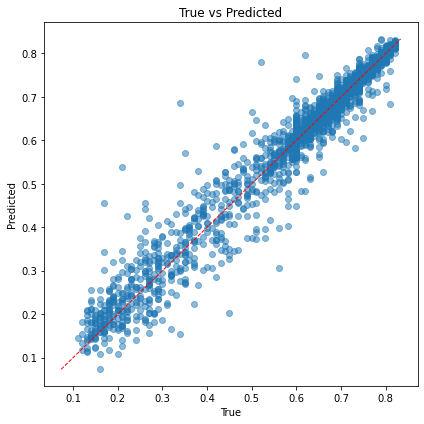


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-5.8703,0.0030,0.0388,0.2439
0.2-0.3,169,-3.8148,0.0043,0.0490,0.2009
0.3-0.4,121,-5.8304,0.0050,0.0515,0.1489
0.4-0.5,120,-3.9510,0.0045,0.0520,0.1163
0.5-0.6,181,-3.8203,0.0031,0.0369,0.0673
0.6-0.7,1006,0.4286,0.0006,0.0153,0.0236
0.7-0.8,1046,0.5617,0.0003,0.0093,0.0125
0.8-0.9,487,-0.5207,0.0001,0.0045,0.0055



Average Segmented Metrics (skip NaN):
  R2:   -2.8521
  MSE:  0.0026
  MAE:  0.0322
  MAPE: 0.1024


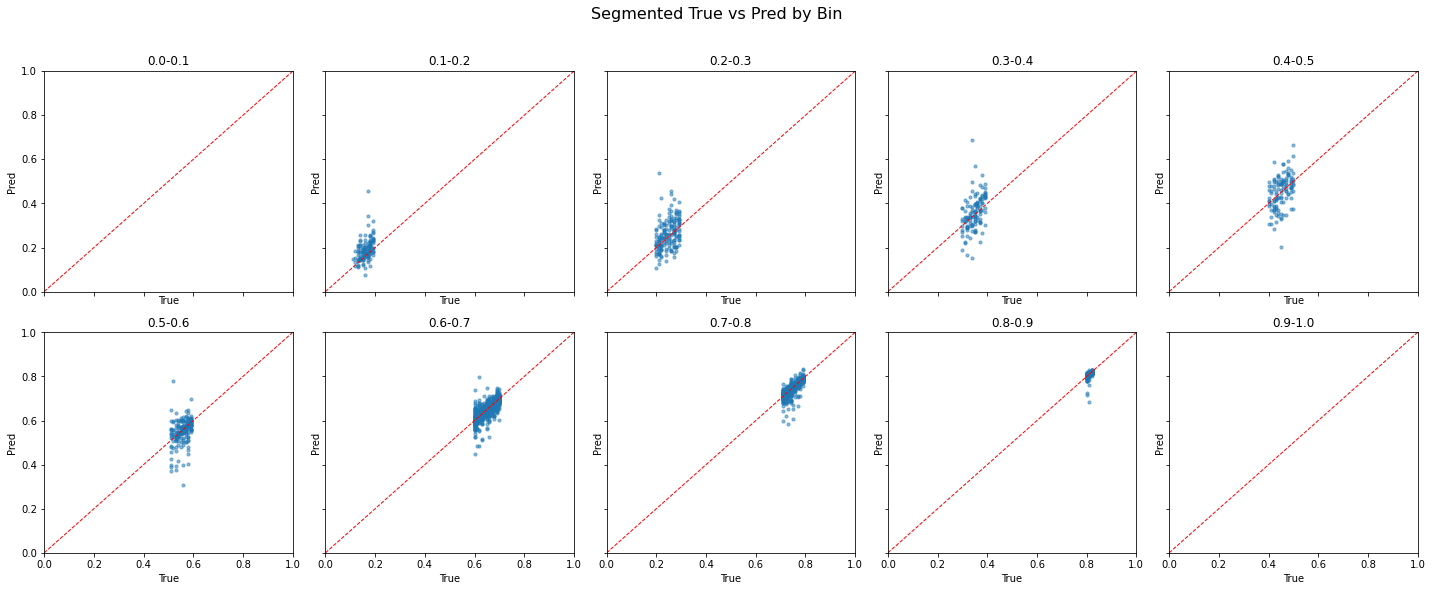

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense

# 构建 Bidirectional LSTM 模型
model_bilstm = Sequential([
    Bidirectional(LSTM(64), input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dense(1)
])

# 编译
model_bilstm.compile(optimizer='adam', loss='mse')

# 训练
model_bilstm.fit(
    X_seq_train, y_train,
    epochs=600, batch_size=32,
    verbose=2  # 关闭 validation_split
)

# 预测 & 评估
y_pred_bilstm = model_bilstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_bilstm)


Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-07-02 19:09:58.420256: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:690] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" vendor: "GenuineIntel" model: "110" frequency: 2300 num_cores: 8 environment { key: "cpu_instruction_set" value: "SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 524288 l3_cache_size: 8388608 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


407/407 - 4s - loss: 0.0193 - 4s/epoch - 10ms/step
Epoch 2/600
407/407 - 2s - loss: 0.0068 - 2s/epoch - 4ms/step
Epoch 3/600
407/407 - 2s - loss: 0.0047 - 2s/epoch - 4ms/step
Epoch 4/600
407/407 - 2s - loss: 0.0038 - 2s/epoch - 4ms/step
Epoch 5/600
407/407 - 2s - loss: 0.0032 - 2s/epoch - 4ms/step
Epoch 6/600
407/407 - 2s - loss: 0.0029 - 2s/epoch - 4ms/step
Epoch 7/600
407/407 - 2s - loss: 0.0029 - 2s/epoch - 4ms/step
Epoch 8/600
407/407 - 2s - loss: 0.0027 - 2s/epoch - 4ms/step
Epoch 9/600
407/407 - 2s - loss: 0.0026 - 2s/epoch - 4ms/step
Epoch 10/600
407/407 - 2s - loss: 0.0024 - 2s/epoch - 4ms/step
Epoch 11/600
407/407 - 2s - loss: 0.0023 - 2s/epoch - 4ms/step
Epoch 12/600
407/407 - 2s - loss: 0.0023 - 2s/epoch - 4ms/step
Epoch 13/600
407/407 - 2s - loss: 0.0020 - 2s/epoch - 4ms/step
Epoch 14/600
407/407 - 2s - loss: 0.0020 - 2s/epoch - 4ms/step
Epoch 15/600
407/407 - 2s - loss: 0.0019 - 2s/epoch - 4ms/step
Epoch 16/600
407/407 - 2s - loss: 0.0019 - 2s/epoch - 4ms/step
Epoch 17/600

Epoch 127/600
407/407 - 2s - loss: 4.2128e-04 - 2s/epoch - 4ms/step
Epoch 128/600
407/407 - 2s - loss: 4.0751e-04 - 2s/epoch - 4ms/step
Epoch 129/600
407/407 - 2s - loss: 4.0133e-04 - 2s/epoch - 4ms/step
Epoch 130/600
407/407 - 2s - loss: 3.9660e-04 - 2s/epoch - 4ms/step
Epoch 131/600
407/407 - 2s - loss: 3.9755e-04 - 2s/epoch - 4ms/step
Epoch 132/600
407/407 - 2s - loss: 4.0004e-04 - 2s/epoch - 4ms/step
Epoch 133/600
407/407 - 2s - loss: 3.8047e-04 - 2s/epoch - 4ms/step
Epoch 134/600
407/407 - 2s - loss: 3.6882e-04 - 2s/epoch - 4ms/step
Epoch 135/600
407/407 - 2s - loss: 3.6380e-04 - 2s/epoch - 4ms/step
Epoch 136/600
407/407 - 2s - loss: 3.7467e-04 - 2s/epoch - 4ms/step
Epoch 137/600
407/407 - 2s - loss: 3.5614e-04 - 2s/epoch - 4ms/step
Epoch 138/600
407/407 - 2s - loss: 3.5123e-04 - 2s/epoch - 4ms/step
Epoch 139/600
407/407 - 2s - loss: 3.6150e-04 - 2s/epoch - 4ms/step
Epoch 140/600
407/407 - 2s - loss: 3.4607e-04 - 2s/epoch - 4ms/step
Epoch 141/600
407/407 - 2s - loss: 3.4845e-04 - 

Epoch 248/600
407/407 - 2s - loss: 1.2607e-04 - 2s/epoch - 4ms/step
Epoch 249/600
407/407 - 2s - loss: 1.2909e-04 - 2s/epoch - 4ms/step
Epoch 250/600
407/407 - 2s - loss: 1.2563e-04 - 2s/epoch - 4ms/step
Epoch 251/600
407/407 - 2s - loss: 1.2355e-04 - 2s/epoch - 4ms/step
Epoch 252/600
407/407 - 2s - loss: 1.2306e-04 - 2s/epoch - 6ms/step
Epoch 253/600
407/407 - 2s - loss: 1.2258e-04 - 2s/epoch - 6ms/step
Epoch 254/600
407/407 - 2s - loss: 1.3116e-04 - 2s/epoch - 5ms/step
Epoch 255/600
407/407 - 2s - loss: 1.2341e-04 - 2s/epoch - 5ms/step
Epoch 256/600
407/407 - 2s - loss: 1.2288e-04 - 2s/epoch - 4ms/step
Epoch 257/600
407/407 - 2s - loss: 1.1123e-04 - 2s/epoch - 5ms/step
Epoch 258/600
407/407 - 2s - loss: 1.2051e-04 - 2s/epoch - 4ms/step
Epoch 259/600
407/407 - 2s - loss: 1.2519e-04 - 2s/epoch - 4ms/step
Epoch 260/600
407/407 - 2s - loss: 1.1641e-04 - 2s/epoch - 4ms/step
Epoch 261/600
407/407 - 2s - loss: 1.1952e-04 - 2s/epoch - 5ms/step
Epoch 262/600
407/407 - 2s - loss: 1.1576e-04 - 

...

Epoch 490/600
407/407 - 2s - loss: 5.6540e-05 - 2s/epoch - 4ms/step
Epoch 491/600
407/407 - 2s - loss: 5.7059e-05 - 2s/epoch - 4ms/step
Epoch 492/600
407/407 - 2s - loss: 5.4494e-05 - 2s/epoch - 4ms/step
Epoch 493/600
407/407 - 2s - loss: 5.2891e-05 - 2s/epoch - 4ms/step
Epoch 494/600
407/407 - 2s - loss: 5.5473e-05 - 2s/epoch - 4ms/step
Epoch 495/600
407/407 - 2s - loss: 5.1651e-05 - 2s/epoch - 4ms/step
Epoch 496/600
407/407 - 2s - loss: 4.8156e-05 - 2s/epoch - 4ms/step
Epoch 497/600
407/407 - 2s - loss: 5.3071e-05 - 2s/epoch - 4ms/step
Epoch 498/600
407/407 - 2s - loss: 5.2692e-05 - 2s/epoch - 4ms/step
Epoch 499/600
407/407 - 2s - loss: 4.8287e-05 - 2s/epoch - 4ms/step
Epoch 500/600
407/407 - 2s - loss: 5.1842e-05 - 2s/epoch - 4ms/step
Epoch 501/600
407/407 - 2s - loss: 5.0050e-05 - 2s/epoch - 4ms/step
Epoch 502/600
407/407 - 2s - loss: 5.3078e-05 - 2s/epoch - 4ms/step
Epoch 503/600
407/407 - 2s - loss: 6.1555e-05 - 2s/epoch - 4ms/step
Epoch 504/600
407/407 - 2s - loss: 5.1853e-05 - 

  1/102 [..............................] - ETA: 2:45

2025-07-02 19:26:45.124333: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:690] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" vendor: "GenuineIntel" model: "110" frequency: 2300 num_cores: 8 environment { key: "cpu_instruction_set" value: "SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 524288 l3_cache_size: 8388608 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


102/102 [==============================] - 2s 2ms/step
Overall Metrics:


,Value
Metric,
MSE,0.0013
MAE,0.0205
MAPE,0.0476
R2,0.9577


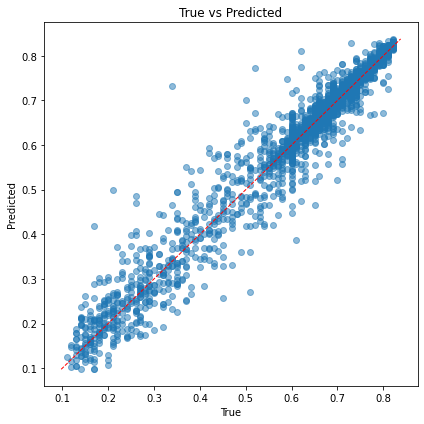


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-4.5583,0.0024,0.0351,0.2207
0.2-0.3,169,-3.4816,0.0040,0.0462,0.1899
0.3-0.4,121,-6.2846,0.0053,0.0521,0.1503
0.4-0.5,120,-4.7899,0.0052,0.0563,0.1251
0.5-0.6,181,-4.2380,0.0034,0.0402,0.0737
0.6-0.7,1006,0.0748,0.0009,0.0189,0.0292
0.7-0.8,1046,0.4389,0.0003,0.0110,0.0148
0.8-0.9,487,-1.1721,0.0001,0.0074,0.0092



Average Segmented Metrics (skip NaN):
  R2:   -3.0013
  MSE:  0.0027
  MAE:  0.0334
  MAPE: 0.1016


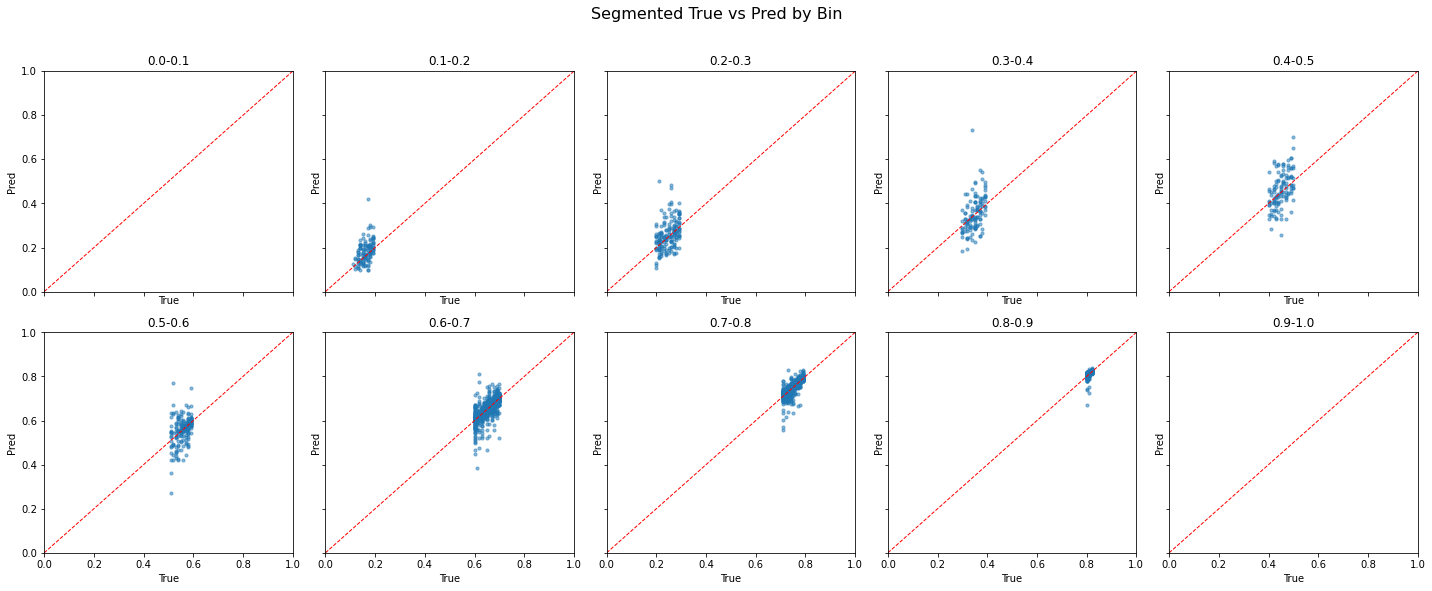

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate, RepeatVector

# LSTM + Attention 自定义模型
input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]))
lstm_out = LSTM(64, return_sequences=True)(input_seq)

# 注意力机制
attention = Attention()([lstm_out, lstm_out])
context = tf.reduce_mean(attention, axis=1)  # 聚合注意力上下文

# 输出层
output = Dense(1)(context)

# 构建模型
model_lstm_att = Model(inputs=input_seq, outputs=output)

# 编译模型
model_lstm_att.compile(optimizer='adam', loss='mse')

# 训练模型
model_lstm_att.fit(
    X_seq_train, y_train,
    epochs=600, batch_size=32,
    verbose=2
)

# 预测并评估
y_pred_att = model_lstm_att.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_att)


Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 9s - loss: 0.0175 - 9s/epoch - 21ms/step
Epoch 2/600
407/407 - 3s - loss: 0.0050 - 3s/epoch - 7ms/step
Epoch 3/600
407/407 - 3s - loss: 0.0034 - 3s/epoch - 7ms/step
Epoch 4/600
407/407 - 3s - loss: 0.0029 - 3s/epoch - 7ms/step
Epoch 5/600
407/407 - 3s - loss: 0.0025 - 3s/epoch - 7ms/step
Epoch 6/600
407/407 - 3s - loss: 0.0022 - 3s/epoch - 7ms/step
Epoch

Epoch 112/600
407/407 - 3s - loss: 2.1831e-04 - 3s/epoch - 6ms/step
Epoch 113/600
407/407 - 3s - loss: 2.2822e-04 - 3s/epoch - 6ms/step
Epoch 114/600
407/407 - 2s - loss: 1.9387e-04 - 2s/epoch - 6ms/step
Epoch 115/600
407/407 - 3s - loss: 1.9623e-04 - 3s/epoch - 6ms/step
Epoch 116/600
407/407 - 3s - loss: 1.9096e-04 - 3s/epoch - 7ms/step
Epoch 117/600
407/407 - 3s - loss: 1.8311e-04 - 3s/epoch - 7ms/step
Epoch 118/600
407/407 - 3s - loss: 1.8729e-04 - 3s/epoch - 6ms/step
Epoch 119/600
407/407 - 3s - loss: 1.8115e-04 - 3s/epoch - 6ms/step
Epoch 120/600
407/407 - 2s - loss: 1.9199e-04 - 2s/epoch - 6ms/step
Epoch 121/600
407/407 - 3s - loss: 1.9501e-04 - 3s/epoch - 6ms/step
Epoch 122/600
407/407 - 3s - loss: 1.6604e-04 - 3s/epoch - 7ms/step
Epoch 123/600
407/407 - 3s - loss: 1.7623e-04 - 3s/epoch - 7ms/step
Epoch 124/600
407/407 - 3s - loss: 1.7074e-04 - 3s/epoch - 6ms/step
Epoch 125/600
407/407 - 3s - loss: 1.7388e-04 - 3s/epoch - 6ms/step
Epoch 126/600
407/407 - 2s - loss: 1.6524e-04 - 

Epoch 233/600
407/407 - 3s - loss: 6.9698e-05 - 3s/epoch - 7ms/step
Epoch 234/600
407/407 - 3s - loss: 6.6636e-05 - 3s/epoch - 7ms/step
Epoch 235/600
407/407 - 2s - loss: 6.4295e-05 - 2s/epoch - 6ms/step
Epoch 236/600
407/407 - 3s - loss: 5.9149e-05 - 3s/epoch - 6ms/step
Epoch 237/600
407/407 - 2s - loss: 6.1803e-05 - 2s/epoch - 6ms/step
Epoch 238/600
407/407 - 2s - loss: 7.1061e-05 - 2s/epoch - 6ms/step
Epoch 239/600
407/407 - 2s - loss: 6.8865e-05 - 2s/epoch - 6ms/step
Epoch 240/600
407/407 - 3s - loss: 6.0371e-05 - 3s/epoch - 6ms/step
Epoch 241/600
407/407 - 3s - loss: 5.9580e-05 - 3s/epoch - 6ms/step
Epoch 242/600
407/407 - 3s - loss: 6.2262e-05 - 3s/epoch - 6ms/step
Epoch 243/600
407/407 - 2s - loss: 6.6598e-05 - 2s/epoch - 6ms/step
Epoch 244/600
407/407 - 3s - loss: 6.0845e-05 - 3s/epoch - 6ms/step
Epoch 245/600
407/407 - 3s - loss: 5.8481e-05 - 3s/epoch - 6ms/step
Epoch 246/600
407/407 - 2s - loss: 6.4071e-05 - 2s/epoch - 6ms/step
Epoch 247/600
407/407 - 2s - loss: 6.3983e-05 - 

Epoch 354/600
407/407 - 3s - loss: 4.0966e-05 - 3s/epoch - 6ms/step
Epoch 355/600
407/407 - 2s - loss: 4.4257e-05 - 2s/epoch - 6ms/step
Epoch 356/600
407/407 - 2s - loss: 4.0843e-05 - 2s/epoch - 6ms/step
Epoch 357/600
407/407 - 3s - loss: 3.5992e-05 - 3s/epoch - 6ms/step
Epoch 358/600
407/407 - 3s - loss: 3.7562e-05 - 3s/epoch - 7ms/step
Epoch 359/600
407/407 - 3s - loss: 4.0500e-05 - 3s/epoch - 6ms/step
Epoch 360/600
407/407 - 2s - loss: 4.2123e-05 - 2s/epoch - 6ms/step
Epoch 361/600
407/407 - 2s - loss: 3.5001e-05 - 2s/epoch - 6ms/step
Epoch 362/600
407/407 - 3s - loss: 4.3586e-05 - 3s/epoch - 6ms/step
Epoch 363/600
407/407 - 3s - loss: 4.0390e-05 - 3s/epoch - 7ms/step
Epoch 364/600
407/407 - 3s - loss: 3.9172e-05 - 3s/epoch - 7ms/step
Epoch 365/600
407/407 - 3s - loss: 3.8648e-05 - 3s/epoch - 7ms/step
Epoch 366/600
407/407 - 3s - loss: 3.8598e-05 - 3s/epoch - 7ms/step
Epoch 367/600
407/407 - 3s - loss: 3.9550e-05 - 3s/epoch - 6ms/step
Epoch 368/600
407/407 - 3s - loss: 3.6651e-05 - 

Epoch 475/600
407/407 - 3s - loss: 3.1323e-05 - 3s/epoch - 7ms/step
Epoch 476/600
407/407 - 3s - loss: 3.2436e-05 - 3s/epoch - 7ms/step
Epoch 477/600
407/407 - 3s - loss: 2.8209e-05 - 3s/epoch - 7ms/step
Epoch 478/600
407/407 - 3s - loss: 2.6208e-05 - 3s/epoch - 7ms/step
Epoch 479/600
407/407 - 3s - loss: 2.6039e-05 - 3s/epoch - 8ms/step
Epoch 480/600
407/407 - 3s - loss: 3.2531e-05 - 3s/epoch - 7ms/step
Epoch 481/600
407/407 - 3s - loss: 3.3804e-05 - 3s/epoch - 8ms/step
Epoch 482/600
407/407 - 3s - loss: 3.3307e-05 - 3s/epoch - 7ms/step
Epoch 483/600
407/407 - 3s - loss: 2.9480e-05 - 3s/epoch - 7ms/step
Epoch 484/600
407/407 - 3s - loss: 2.8536e-05 - 3s/epoch - 8ms/step
Epoch 485/600
407/407 - 3s - loss: 2.8333e-05 - 3s/epoch - 7ms/step
Epoch 486/600
407/407 - 3s - loss: 3.0485e-05 - 3s/epoch - 6ms/step
Epoch 487/600
407/407 - 3s - loss: 3.1353e-05 - 3s/epoch - 8ms/step
Epoch 488/600
407/407 - 3s - loss: 2.8750e-05 - 3s/epoch - 7ms/step
Epoch 489/600
407/407 - 3s - loss: 2.8647e-05 - 

Epoch 596/600
407/407 - 4s - loss: 2.3559e-05 - 4s/epoch - 9ms/step
Epoch 597/600
407/407 - 3s - loss: 2.3342e-05 - 3s/epoch - 8ms/step
Epoch 598/600
407/407 - 3s - loss: 2.3863e-05 - 3s/epoch - 8ms/step
Epoch 599/600
407/407 - 3s - loss: 2.4635e-05 - 3s/epoch - 8ms/step
Epoch 600/600
407/407 - 3s - loss: 2.4243e-05 - 3s/epoch - 7ms/step
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
102/102 [=============================

,Value
Metric,
MSE,0.0010
MAE,0.0162
MAPE,0.0394
R2,0.9681


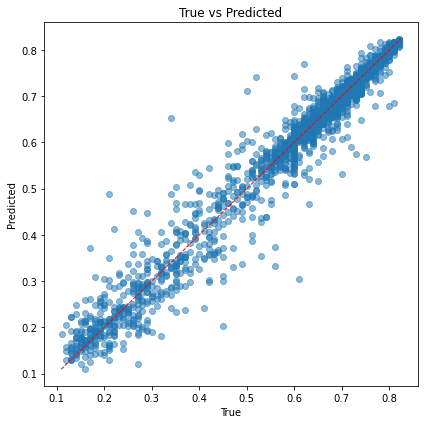


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-3.3775,0.0019,0.0309,0.1984
0.2-0.3,169,-2.8354,0.0034,0.0411,0.1686
0.3-0.4,121,-4.3170,0.0039,0.0453,0.1305
0.4-0.5,120,-4.3806,0.0049,0.0527,0.1178
0.5-0.6,181,-2.4018,0.0022,0.0300,0.0549
0.6-0.7,1006,0.3910,0.0006,0.0142,0.0219
0.7-0.8,1046,0.5979,0.0002,0.0083,0.0112
0.8-0.9,487,-0.4025,0.0001,0.0034,0.0043



Average Segmented Metrics (skip NaN):
  R2:   -2.0907
  MSE:  0.0021
  MAE:  0.0282
  MAPE: 0.0884


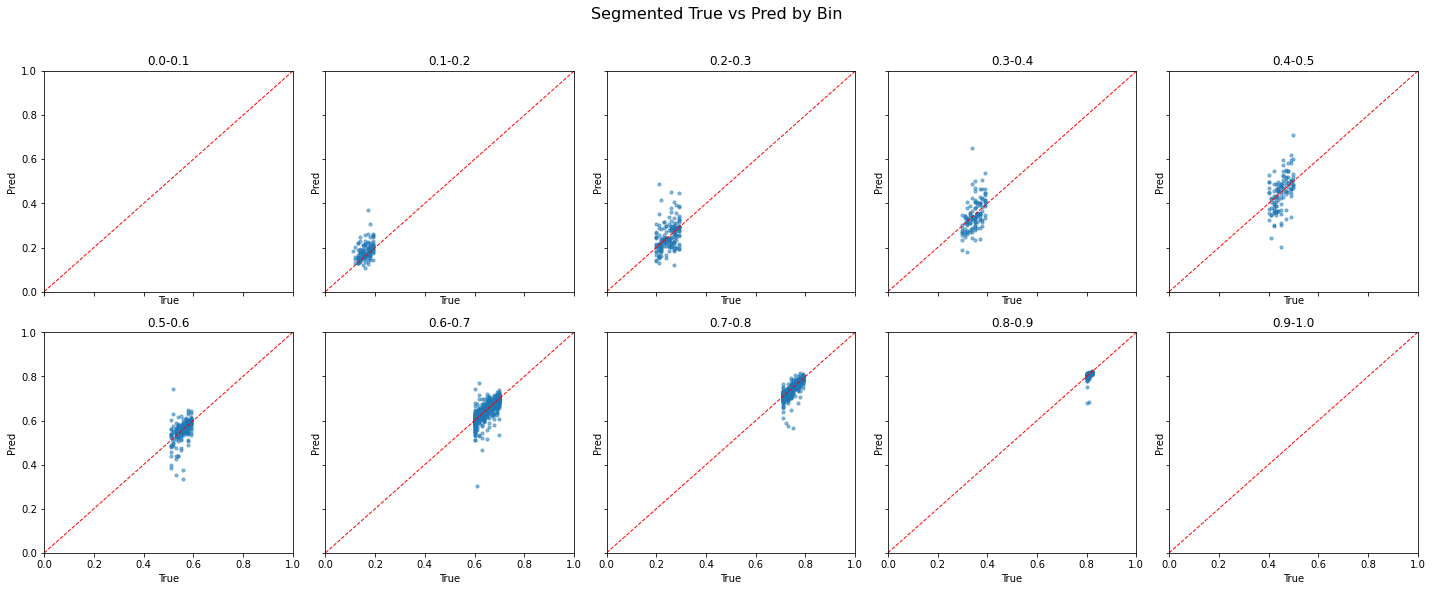

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 构建 Stacked LSTM 模型
model_stacked_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),  # 第二层 LSTM
    Dense(1)   # 输出层
])

model_stacked_lstm.compile(optimizer='adam', loss='mse')

# 训练
model_stacked_lstm.fit(
    X_seq_train, y_train,
    epochs=600, batch_size=32,
    verbose=2
)

# 预测 + 评估
y_pred_stacked = model_stacked_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_stacked)


Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 8s - loss: 0.0140 - 8s/epoch - 19ms/step
Epoch 2/600
407/407 - 2s - loss: 0.0045 - 2s/epoch - 6ms/step
Epoch 3/600
407/407 - 2s - loss: 0.0032 - 2s/epoch - 6ms/step
Epoch 4/600
407/407 - 2s - loss: 0.0029 - 2s/epoch - 6ms/step
Epoch 5/600
407/407 - 2s - loss: 0.0026 - 2s/epoch - 5ms/step
Epoch 6/600
407/407 - 2s - loss: 0.0024 - 2s/epoch - 6ms/step
Epoch

Epoch 112/600
407/407 - 2s - loss: 2.9573e-04 - 2s/epoch - 6ms/step
Epoch 113/600
407/407 - 2s - loss: 2.9330e-04 - 2s/epoch - 5ms/step
Epoch 114/600
407/407 - 2s - loss: 2.9324e-04 - 2s/epoch - 5ms/step
Epoch 115/600
407/407 - 2s - loss: 3.0775e-04 - 2s/epoch - 5ms/step
Epoch 116/600
407/407 - 2s - loss: 2.7572e-04 - 2s/epoch - 5ms/step
Epoch 117/600
407/407 - 2s - loss: 2.8487e-04 - 2s/epoch - 5ms/step
Epoch 118/600
407/407 - 2s - loss: 2.6655e-04 - 2s/epoch - 5ms/step
Epoch 119/600
407/407 - 2s - loss: 2.6498e-04 - 2s/epoch - 5ms/step
Epoch 120/600
407/407 - 2s - loss: 2.6009e-04 - 2s/epoch - 5ms/step
Epoch 121/600
407/407 - 2s - loss: 2.4921e-04 - 2s/epoch - 5ms/step
Epoch 122/600
407/407 - 2s - loss: 2.5890e-04 - 2s/epoch - 5ms/step
Epoch 123/600
407/407 - 2s - loss: 2.6109e-04 - 2s/epoch - 6ms/step
Epoch 124/600
407/407 - 2s - loss: 2.5452e-04 - 2s/epoch - 5ms/step
Epoch 125/600
407/407 - 2s - loss: 2.4527e-04 - 2s/epoch - 5ms/step
Epoch 126/600
407/407 - 2s - loss: 2.3784e-04 - 

Epoch 233/600
407/407 - 2s - loss: 8.1440e-05 - 2s/epoch - 5ms/step
Epoch 234/600
407/407 - 2s - loss: 8.4360e-05 - 2s/epoch - 5ms/step
Epoch 235/600
407/407 - 2s - loss: 8.5107e-05 - 2s/epoch - 5ms/step
Epoch 236/600
407/407 - 2s - loss: 7.7451e-05 - 2s/epoch - 5ms/step
Epoch 237/600
407/407 - 3s - loss: 8.5157e-05 - 3s/epoch - 6ms/step
Epoch 238/600
407/407 - 2s - loss: 8.0922e-05 - 2s/epoch - 6ms/step
Epoch 239/600
407/407 - 3s - loss: 7.9317e-05 - 3s/epoch - 6ms/step
Epoch 240/600
407/407 - 2s - loss: 9.3642e-05 - 2s/epoch - 6ms/step
Epoch 241/600
407/407 - 2s - loss: 7.6387e-05 - 2s/epoch - 6ms/step
Epoch 242/600
407/407 - 2s - loss: 7.4478e-05 - 2s/epoch - 5ms/step
Epoch 243/600
407/407 - 2s - loss: 7.4915e-05 - 2s/epoch - 6ms/step
Epoch 244/600
407/407 - 2s - loss: 7.1981e-05 - 2s/epoch - 5ms/step
Epoch 245/600
407/407 - 2s - loss: 7.6340e-05 - 2s/epoch - 6ms/step
Epoch 246/600
407/407 - 2s - loss: 7.7369e-05 - 2s/epoch - 6ms/step
Epoch 247/600
407/407 - 2s - loss: 7.9568e-05 - 

Epoch 354/600
407/407 - 2s - loss: 5.0463e-05 - 2s/epoch - 5ms/step
Epoch 355/600
407/407 - 2s - loss: 5.0317e-05 - 2s/epoch - 5ms/step
Epoch 356/600
407/407 - 2s - loss: 4.6998e-05 - 2s/epoch - 5ms/step
Epoch 357/600
407/407 - 2s - loss: 4.6322e-05 - 2s/epoch - 5ms/step
Epoch 358/600
407/407 - 2s - loss: 4.6403e-05 - 2s/epoch - 4ms/step
Epoch 359/600
407/407 - 2s - loss: 5.9989e-05 - 2s/epoch - 4ms/step
Epoch 360/600
407/407 - 2s - loss: 5.0365e-05 - 2s/epoch - 4ms/step
Epoch 361/600
407/407 - 2s - loss: 4.5886e-05 - 2s/epoch - 4ms/step
Epoch 362/600
407/407 - 2s - loss: 4.4911e-05 - 2s/epoch - 5ms/step
Epoch 363/600
407/407 - 2s - loss: 4.7207e-05 - 2s/epoch - 5ms/step
Epoch 364/600
407/407 - 2s - loss: 4.3773e-05 - 2s/epoch - 5ms/step
Epoch 365/600
407/407 - 2s - loss: 4.9481e-05 - 2s/epoch - 5ms/step
Epoch 366/600
407/407 - 2s - loss: 5.0062e-05 - 2s/epoch - 5ms/step
Epoch 367/600
407/407 - 2s - loss: 4.4544e-05 - 2s/epoch - 5ms/step
Epoch 368/600
407/407 - 2s - loss: 4.6893e-05 - 

Epoch 475/600
407/407 - 2s - loss: 3.9684e-05 - 2s/epoch - 5ms/step
Epoch 476/600
407/407 - 2s - loss: 4.3890e-05 - 2s/epoch - 5ms/step
Epoch 477/600
407/407 - 2s - loss: 3.7159e-05 - 2s/epoch - 5ms/step
Epoch 478/600
407/407 - 2s - loss: 3.4028e-05 - 2s/epoch - 5ms/step
Epoch 479/600
407/407 - 2s - loss: 3.1494e-05 - 2s/epoch - 5ms/step
Epoch 480/600
407/407 - 2s - loss: 3.3150e-05 - 2s/epoch - 5ms/step
Epoch 481/600
407/407 - 2s - loss: 3.4619e-05 - 2s/epoch - 5ms/step
Epoch 482/600
407/407 - 2s - loss: 4.0934e-05 - 2s/epoch - 5ms/step
Epoch 483/600
407/407 - 2s - loss: 3.7049e-05 - 2s/epoch - 5ms/step
Epoch 484/600
407/407 - 2s - loss: 3.7471e-05 - 2s/epoch - 6ms/step
Epoch 485/600
407/407 - 3s - loss: 3.3561e-05 - 3s/epoch - 6ms/step
Epoch 486/600
407/407 - 2s - loss: 3.1530e-05 - 2s/epoch - 6ms/step
Epoch 487/600
407/407 - 2s - loss: 3.4908e-05 - 2s/epoch - 5ms/step
Epoch 488/600
407/407 - 2s - loss: 3.5340e-05 - 2s/epoch - 6ms/step
Epoch 489/600
407/407 - 2s - loss: 3.4952e-05 - 

Epoch 596/600
407/407 - 2s - loss: 2.8314e-05 - 2s/epoch - 6ms/step
Epoch 597/600
407/407 - 2s - loss: 2.8486e-05 - 2s/epoch - 5ms/step
Epoch 598/600
407/407 - 2s - loss: 2.6524e-05 - 2s/epoch - 5ms/step
Epoch 599/600
407/407 - 2s - loss: 2.7926e-05 - 2s/epoch - 4ms/step
Epoch 600/600
407/407 - 2s - loss: 2.7870e-05 - 2s/epoch - 6ms/step
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
102/102 [=============================

,Value
Metric,
MSE,0.0011
MAE,0.0179
MAPE,0.0435
R2,0.9651


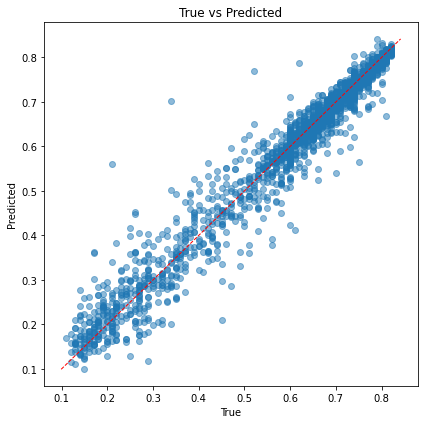


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-5.0877,0.0026,0.0373,0.2355
0.2-0.3,169,-3.9106,0.0044,0.0479,0.1947
0.3-0.4,121,-4.6408,0.0041,0.0444,0.1283
0.4-0.5,120,-3.5242,0.0041,0.0477,0.1064
0.5-0.6,181,-2.8304,0.0025,0.0333,0.0604
0.6-0.7,1006,0.4285,0.0006,0.0150,0.0231
0.7-0.8,1046,0.4624,0.0003,0.0102,0.0137
0.8-0.9,487,-0.9813,0.0001,0.0055,0.0068



Average Segmented Metrics (skip NaN):
  R2:   -2.5105
  MSE:  0.0023
  MAE:  0.0301
  MAPE: 0.0961


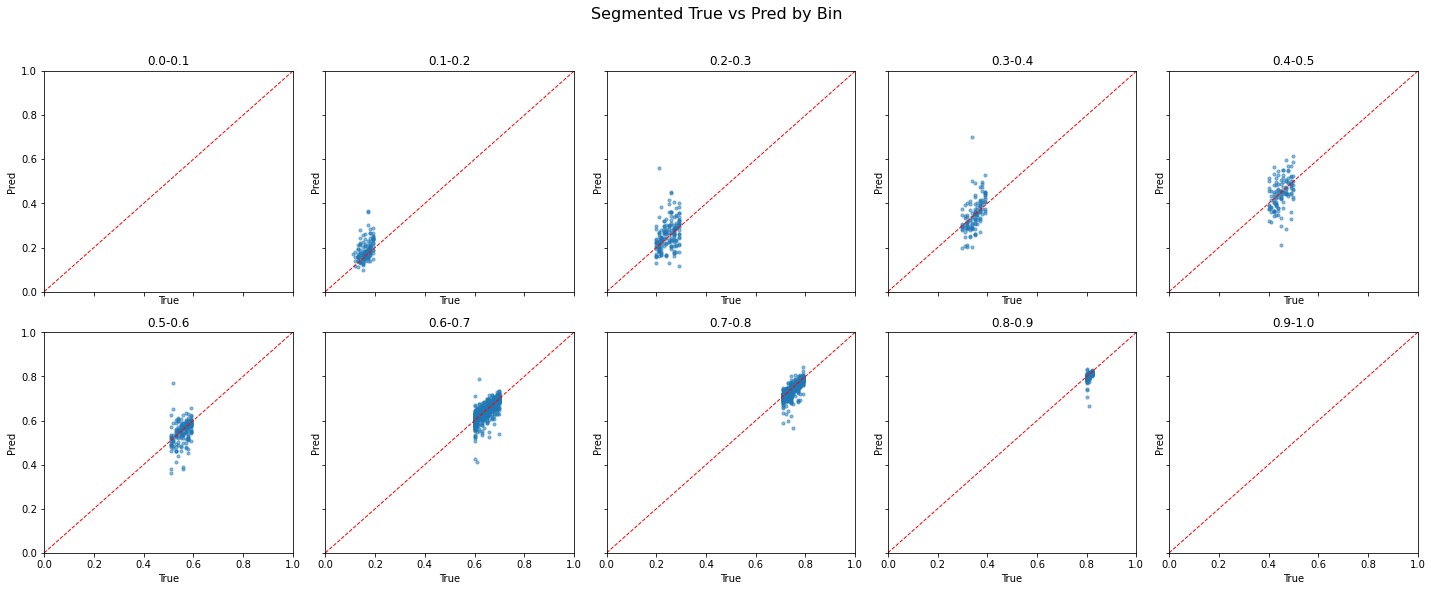

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional

# 构建 Bidirectional LSTM 模型
model_bi_lstm = Sequential([
    Bidirectional(LSTM(64), input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dense(1)
])

model_bi_lstm.compile(optimizer='adam', loss='mse')

# 训练
model_bi_lstm.fit(
    X_seq_train, y_train,
    epochs=600, batch_size=32,
    verbose=2
)

# 预测 + 评估
y_pred_bilstm = model_bi_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_bilstm)



--- 3-Layer Stacked LSTM ---
Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 19s - loss: 0.0177 - 19s/epoch - 46ms/step
Epoch 2/600
407/407 - 6s - loss: 0.0069 - 6s/epoch - 16ms/step
Epoch 3/600
407/407 - 6s - loss: 0.0044 - 6s/epoch - 16ms/step
Epoch 4/600
407/407 - 7s - loss: 0.0035 - 7s/epoch - 17ms/step
Epoch 5/600
407/407 - 6s - loss: 0.0029 - 6s/epoch - 14ms/step
Epoch 6/600
407/407 - 7s - loss

Epoch 110/600
407/407 - 8s - loss: 3.0805e-04 - 8s/epoch - 19ms/step
Epoch 111/600
407/407 - 7s - loss: 3.0712e-04 - 7s/epoch - 18ms/step
Epoch 112/600
407/407 - 7s - loss: 3.1810e-04 - 7s/epoch - 17ms/step
Epoch 113/600
407/407 - 6s - loss: 3.0286e-04 - 6s/epoch - 14ms/step
Epoch 114/600
407/407 - 8s - loss: 2.8972e-04 - 8s/epoch - 18ms/step
Epoch 115/600
407/407 - 7s - loss: 2.9715e-04 - 7s/epoch - 17ms/step
Epoch 116/600
407/407 - 7s - loss: 3.0183e-04 - 7s/epoch - 16ms/step
Epoch 117/600
407/407 - 6s - loss: 2.7687e-04 - 6s/epoch - 15ms/step
Epoch 118/600
407/407 - 7s - loss: 3.1681e-04 - 7s/epoch - 17ms/step
Epoch 119/600
407/407 - 7s - loss: 2.9378e-04 - 7s/epoch - 16ms/step
Epoch 120/600
407/407 - 7s - loss: 3.0026e-04 - 7s/epoch - 17ms/step
Epoch 121/600
407/407 - 6s - loss: 2.9486e-04 - 6s/epoch - 14ms/step
Epoch 122/600
407/407 - 7s - loss: 2.7169e-04 - 7s/epoch - 16ms/step
Epoch 123/600
407/407 - 6s - loss: 2.7461e-04 - 6s/epoch - 16ms/step
Epoch 124/600
407/407 - 6s - loss:

Epoch 229/600
407/407 - 6s - loss: 1.4029e-04 - 6s/epoch - 15ms/step
Epoch 230/600
407/407 - 6s - loss: 1.4201e-04 - 6s/epoch - 14ms/step
Epoch 231/600
407/407 - 6s - loss: 1.4359e-04 - 6s/epoch - 14ms/step
Epoch 232/600
407/407 - 5s - loss: 1.4205e-04 - 5s/epoch - 13ms/step
Epoch 233/600
407/407 - 6s - loss: 1.3584e-04 - 6s/epoch - 14ms/step
Epoch 234/600
407/407 - 6s - loss: 1.3340e-04 - 6s/epoch - 14ms/step
Epoch 235/600
407/407 - 6s - loss: 1.9750e-04 - 6s/epoch - 14ms/step
Epoch 236/600
407/407 - 5s - loss: 1.3873e-04 - 5s/epoch - 13ms/step
Epoch 237/600
407/407 - 5s - loss: 1.3477e-04 - 5s/epoch - 13ms/step
Epoch 238/600
407/407 - 6s - loss: 1.3751e-04 - 6s/epoch - 14ms/step
Epoch 239/600
407/407 - 6s - loss: 1.3309e-04 - 6s/epoch - 14ms/step
Epoch 240/600
407/407 - 6s - loss: 1.3477e-04 - 6s/epoch - 14ms/step
Epoch 241/600
407/407 - 6s - loss: 1.3452e-04 - 6s/epoch - 15ms/step
Epoch 242/600
407/407 - 5s - loss: 1.3820e-04 - 5s/epoch - 13ms/step
Epoch 243/600
407/407 - 6s - loss:

Epoch 348/600
407/407 - 5s - loss: 9.9968e-05 - 5s/epoch - 13ms/step
Epoch 349/600
407/407 - 5s - loss: 1.0043e-04 - 5s/epoch - 13ms/step
Epoch 350/600
407/407 - 6s - loss: 1.0427e-04 - 6s/epoch - 14ms/step
Epoch 351/600
407/407 - 6s - loss: 9.8830e-05 - 6s/epoch - 14ms/step
Epoch 352/600
407/407 - 6s - loss: 9.4369e-05 - 6s/epoch - 15ms/step
Epoch 353/600
407/407 - 5s - loss: 9.8270e-05 - 5s/epoch - 13ms/step
Epoch 354/600
407/407 - 5s - loss: 1.0033e-04 - 5s/epoch - 13ms/step
Epoch 355/600
407/407 - 5s - loss: 9.9772e-05 - 5s/epoch - 13ms/step
Epoch 356/600
407/407 - 6s - loss: 1.0399e-04 - 6s/epoch - 15ms/step
Epoch 357/600
407/407 - 6s - loss: 1.1689e-04 - 6s/epoch - 15ms/step
Epoch 358/600
407/407 - 6s - loss: 9.9785e-05 - 6s/epoch - 14ms/step
Epoch 359/600
407/407 - 5s - loss: 9.4332e-05 - 5s/epoch - 13ms/step
Epoch 360/600
407/407 - 5s - loss: 9.6607e-05 - 5s/epoch - 13ms/step
Epoch 361/600
407/407 - 6s - loss: 9.5168e-05 - 6s/epoch - 14ms/step
Epoch 362/600
407/407 - 6s - loss:

Epoch 467/600
407/407 - 6s - loss: 7.5888e-05 - 6s/epoch - 15ms/step
Epoch 468/600
407/407 - 7s - loss: 8.0695e-05 - 7s/epoch - 17ms/step
Epoch 469/600
407/407 - 6s - loss: 7.9432e-05 - 6s/epoch - 15ms/step
Epoch 470/600
407/407 - 7s - loss: 8.0353e-05 - 7s/epoch - 16ms/step
Epoch 471/600
407/407 - 6s - loss: 7.8151e-05 - 6s/epoch - 15ms/step
Epoch 472/600
407/407 - 6s - loss: 7.8935e-05 - 6s/epoch - 15ms/step
Epoch 473/600
407/407 - 6s - loss: 7.5794e-05 - 6s/epoch - 15ms/step
Epoch 474/600
407/407 - 6s - loss: 7.3519e-05 - 6s/epoch - 15ms/step
Epoch 475/600
407/407 - 6s - loss: 7.8384e-05 - 6s/epoch - 15ms/step
Epoch 476/600
407/407 - 6s - loss: 7.7348e-05 - 6s/epoch - 15ms/step
Epoch 477/600
407/407 - 6s - loss: 7.4280e-05 - 6s/epoch - 15ms/step
Epoch 478/600
407/407 - 6s - loss: 7.4918e-05 - 6s/epoch - 16ms/step
Epoch 479/600
407/407 - 6s - loss: 8.1652e-05 - 6s/epoch - 15ms/step
Epoch 480/600
407/407 - 6s - loss: 7.4531e-05 - 6s/epoch - 16ms/step
Epoch 481/600
407/407 - 7s - loss:

Epoch 586/600
407/407 - 7s - loss: 6.8896e-05 - 7s/epoch - 16ms/step
Epoch 587/600
407/407 - 6s - loss: 6.4421e-05 - 6s/epoch - 16ms/step
Epoch 588/600
407/407 - 5s - loss: 6.4619e-05 - 5s/epoch - 13ms/step
Epoch 589/600
407/407 - 6s - loss: 6.3286e-05 - 6s/epoch - 14ms/step
Epoch 590/600
407/407 - 5s - loss: 6.2218e-05 - 5s/epoch - 13ms/step
Epoch 591/600
407/407 - 5s - loss: 6.5676e-05 - 5s/epoch - 13ms/step
Epoch 592/600
407/407 - 5s - loss: 6.6421e-05 - 5s/epoch - 13ms/step
Epoch 593/600
407/407 - 6s - loss: 7.6266e-05 - 6s/epoch - 15ms/step
Epoch 594/600
407/407 - 5s - loss: 6.1672e-05 - 5s/epoch - 13ms/step
Epoch 595/600
407/407 - 5s - loss: 6.1371e-05 - 5s/epoch - 13ms/step
Epoch 596/600
407/407 - 5s - loss: 6.1428e-05 - 5s/epoch - 13ms/step
Epoch 597/600
407/407 - 6s - loss: 6.1003e-05 - 6s/epoch - 14ms/step
Epoch 598/600
407/407 - 6s - loss: 6.1598e-05 - 6s/epoch - 14ms/step
Epoch 599/600
407/407 - 6s - loss: 6.3445e-05 - 6s/epoch - 14ms/step
Epoch 600/600
407/407 - 6s - loss:

,Value
Metric,
MSE,0.0010
MAE,0.0166
MAPE,0.0415
R2,0.9660


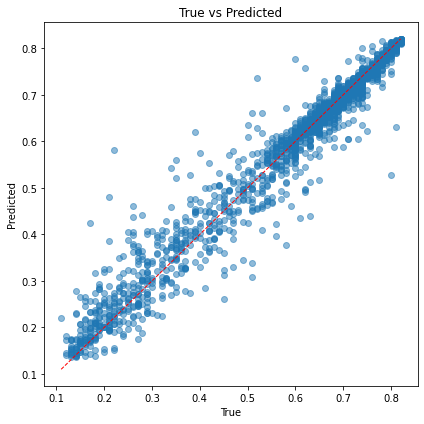


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-5.1293,0.0027,0.0356,0.2240
0.2-0.3,169,-4.4002,0.0048,0.0476,0.1953
0.3-0.4,121,-4.3446,0.0039,0.0468,0.1352
0.4-0.5,120,-2.8407,0.0035,0.0443,0.0992
0.5-0.6,181,-3.2355,0.0028,0.0357,0.0653
0.6-0.7,1006,0.5188,0.0005,0.0126,0.0193
0.7-0.8,1046,0.6043,0.0002,0.0089,0.0119
0.8-0.9,487,-3.2579,0.0003,0.0046,0.0057



Average Segmented Metrics (skip NaN):
  R2:   -2.7606
  MSE:  0.0023
  MAE:  0.0295
  MAPE: 0.0945


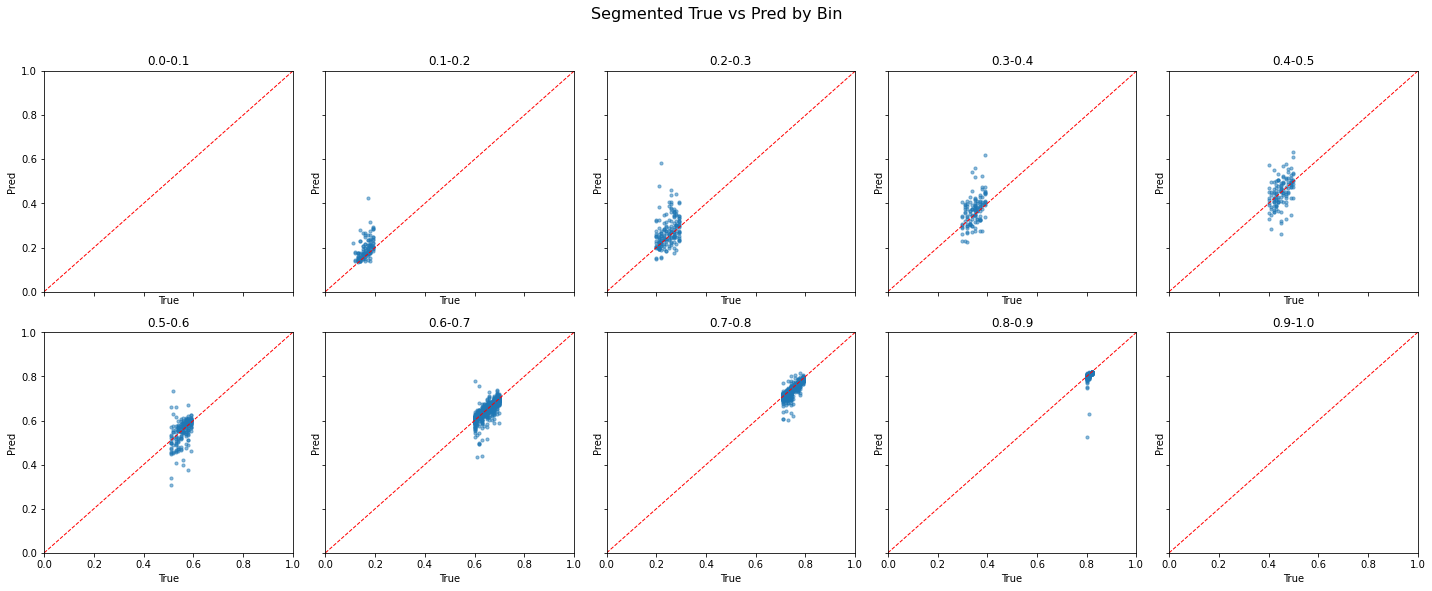

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_deep_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model_deep_lstm.compile(optimizer='adam', loss='mse')

print("\n--- 3-Layer Stacked LSTM ---")
model_deep_lstm.fit(
    X_seq_train, y_train,
    epochs=600,
    batch_size=32,
    verbose=2
)

y_pred_deep_lstm = model_deep_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_deep_lstm)


Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing 

Epoch 98/600
407/407 - 3s - loss: 1.2694e-04 - 3s/epoch - 8ms/step
Epoch 99/600
407/407 - 3s - loss: 1.2772e-04 - 3s/epoch - 7ms/step
Epoch 100/600
407/407 - 3s - loss: 1.2964e-04 - 3s/epoch - 7ms/step
Epoch 101/600
407/407 - 3s - loss: 1.1783e-04 - 3s/epoch - 7ms/step
Epoch 102/600
407/407 - 3s - loss: 1.2250e-04 - 3s/epoch - 8ms/step
Epoch 103/600
407/407 - 3s - loss: 1.2060e-04 - 3s/epoch - 7ms/step
Epoch 104/600
407/407 - 3s - loss: 1.2005e-04 - 3s/epoch - 7ms/step
Epoch 105/600
407/407 - 3s - loss: 1.1465e-04 - 3s/epoch - 7ms/step
Epoch 106/600
407/407 - 3s - loss: 1.1758e-04 - 3s/epoch - 7ms/step
Epoch 107/600
407/407 - 3s - loss: 1.0919e-04 - 3s/epoch - 7ms/step
Epoch 108/600
407/407 - 3s - loss: 1.0691e-04 - 3s/epoch - 7ms/step
Epoch 109/600
407/407 - 3s - loss: 1.0457e-04 - 3s/epoch - 7ms/step
Epoch 110/600
407/407 - 3s - loss: 1.0425e-04 - 3s/epoch - 7ms/step
Epoch 111/600
407/407 - 3s - loss: 1.0300e-04 - 3s/epoch - 8ms/step
Epoch 112/600
407/407 - 3s - loss: 1.0721e-04 - 3s

Epoch 219/600
407/407 - 2s - loss: 3.3173e-05 - 2s/epoch - 6ms/step
Epoch 220/600
407/407 - 3s - loss: 3.2120e-05 - 3s/epoch - 6ms/step
Epoch 221/600
407/407 - 3s - loss: 3.2649e-05 - 3s/epoch - 6ms/step
Epoch 222/600
407/407 - 3s - loss: 3.5793e-05 - 3s/epoch - 7ms/step
Epoch 223/600
407/407 - 2s - loss: 3.1421e-05 - 2s/epoch - 6ms/step
Epoch 224/600
407/407 - 3s - loss: 3.3293e-05 - 3s/epoch - 7ms/step
Epoch 225/600
407/407 - 3s - loss: 3.0717e-05 - 3s/epoch - 6ms/step
Epoch 226/600
407/407 - 3s - loss: 3.3329e-05 - 3s/epoch - 6ms/step
Epoch 227/600
407/407 - 3s - loss: 3.1999e-05 - 3s/epoch - 6ms/step
Epoch 228/600
407/407 - 3s - loss: 3.3426e-05 - 3s/epoch - 7ms/step
Epoch 229/600
407/407 - 3s - loss: 3.3622e-05 - 3s/epoch - 6ms/step
Epoch 230/600
407/407 - 3s - loss: 2.9746e-05 - 3s/epoch - 6ms/step
Epoch 231/600
407/407 - 2s - loss: 3.1685e-05 - 2s/epoch - 6ms/step
Epoch 232/600
407/407 - 2s - loss: 3.1624e-05 - 2s/epoch - 6ms/step
Epoch 233/600
407/407 - 2s - loss: 3.0886e-05 - 

Epoch 340/600
407/407 - 3s - loss: 1.9286e-05 - 3s/epoch - 6ms/step
Epoch 341/600
407/407 - 2s - loss: 2.2691e-05 - 2s/epoch - 6ms/step
Epoch 342/600
407/407 - 3s - loss: 2.0720e-05 - 3s/epoch - 6ms/step
Epoch 343/600
407/407 - 3s - loss: 1.9561e-05 - 3s/epoch - 6ms/step
Epoch 344/600
407/407 - 3s - loss: 1.8450e-05 - 3s/epoch - 6ms/step
Epoch 345/600
407/407 - 2s - loss: 1.8891e-05 - 2s/epoch - 6ms/step
Epoch 346/600
407/407 - 3s - loss: 1.8756e-05 - 3s/epoch - 7ms/step
Epoch 347/600
407/407 - 3s - loss: 2.1136e-05 - 3s/epoch - 6ms/step
Epoch 348/600
407/407 - 3s - loss: 2.0999e-05 - 3s/epoch - 7ms/step
Epoch 349/600
407/407 - 2s - loss: 2.0007e-05 - 2s/epoch - 6ms/step
Epoch 350/600
407/407 - 3s - loss: 2.0918e-05 - 3s/epoch - 6ms/step
Epoch 351/600
407/407 - 3s - loss: 1.6846e-05 - 3s/epoch - 7ms/step
Epoch 352/600
407/407 - 3s - loss: 1.8763e-05 - 3s/epoch - 7ms/step
Epoch 353/600
407/407 - 2s - loss: 2.4437e-05 - 2s/epoch - 6ms/step
Epoch 354/600
407/407 - 3s - loss: 1.8048e-05 - 

Epoch 461/600
407/407 - 3s - loss: 1.4891e-05 - 3s/epoch - 6ms/step
Epoch 462/600
407/407 - 3s - loss: 1.5546e-05 - 3s/epoch - 7ms/step
Epoch 463/600
407/407 - 3s - loss: 1.4454e-05 - 3s/epoch - 7ms/step
Epoch 464/600
407/407 - 3s - loss: 1.5160e-05 - 3s/epoch - 6ms/step
Epoch 465/600
407/407 - 3s - loss: 1.6421e-05 - 3s/epoch - 6ms/step
Epoch 466/600
407/407 - 2s - loss: 1.5536e-05 - 2s/epoch - 6ms/step
Epoch 467/600
407/407 - 3s - loss: 1.3775e-05 - 3s/epoch - 6ms/step
Epoch 468/600
407/407 - 3s - loss: 1.4963e-05 - 3s/epoch - 6ms/step
Epoch 469/600
407/407 - 3s - loss: 1.4644e-05 - 3s/epoch - 7ms/step
Epoch 470/600
407/407 - 3s - loss: 1.3707e-05 - 3s/epoch - 6ms/step
Epoch 471/600
407/407 - 2s - loss: 1.5087e-05 - 2s/epoch - 6ms/step
Epoch 472/600
407/407 - 3s - loss: 1.6169e-05 - 3s/epoch - 6ms/step
Epoch 473/600
407/407 - 3s - loss: 1.4830e-05 - 3s/epoch - 6ms/step
Epoch 474/600
407/407 - 3s - loss: 1.3620e-05 - 3s/epoch - 6ms/step
Epoch 475/600
407/407 - 2s - loss: 1.4482e-05 - 

Epoch 582/600
407/407 - 2s - loss: 1.2375e-05 - 2s/epoch - 6ms/step
Epoch 583/600
407/407 - 3s - loss: 1.1613e-05 - 3s/epoch - 6ms/step
Epoch 584/600
407/407 - 3s - loss: 1.1397e-05 - 3s/epoch - 7ms/step
Epoch 585/600
407/407 - 2s - loss: 1.1469e-05 - 2s/epoch - 6ms/step
Epoch 586/600
407/407 - 3s - loss: 1.1742e-05 - 3s/epoch - 6ms/step
Epoch 587/600
407/407 - 3s - loss: 1.2565e-05 - 3s/epoch - 7ms/step
Epoch 588/600
407/407 - 3s - loss: 1.1866e-05 - 3s/epoch - 7ms/step
Epoch 589/600
407/407 - 3s - loss: 1.2345e-05 - 3s/epoch - 7ms/step
Epoch 590/600
407/407 - 3s - loss: 1.2388e-05 - 3s/epoch - 6ms/step
Epoch 591/600
407/407 - 3s - loss: 1.0604e-05 - 3s/epoch - 6ms/step
Epoch 592/600
407/407 - 2s - loss: 1.3010e-05 - 2s/epoch - 6ms/step
Epoch 593/600
407/407 - 2s - loss: 1.2570e-05 - 2s/epoch - 6ms/step
Epoch 594/600
407/407 - 3s - loss: 1.1387e-05 - 3s/epoch - 6ms/step
Epoch 595/600
407/407 - 3s - loss: 1.0401e-05 - 3s/epoch - 6ms/step
Epoch 596/600
407/407 - 2s - loss: 1.1130e-05 - 

,Value
Metric,
MSE,0.0009
MAE,0.0165
MAPE,0.0399
R2,0.9699


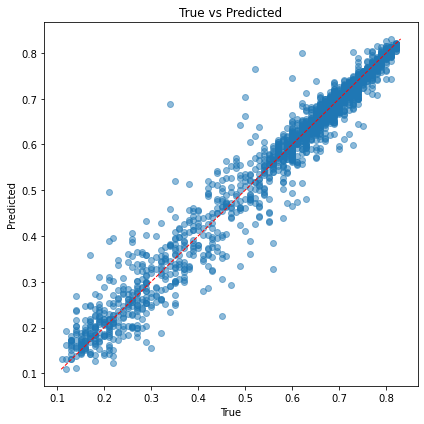


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-3.2845,0.0019,0.0314,0.1995
0.2-0.3,169,-2.8475,0.0034,0.0419,0.1718
0.3-0.4,121,-4.1179,0.0037,0.0448,0.1303
0.4-0.5,120,-4.0989,0.0046,0.0520,0.1156
0.5-0.6,181,-2.7567,0.0024,0.0317,0.0578
0.6-0.7,1006,0.5106,0.0005,0.0140,0.0216
0.7-0.8,1046,0.6430,0.0002,0.0088,0.0118
0.8-0.9,487,0.1653,0.0000,0.0041,0.0050



Average Segmented Metrics (skip NaN):
  R2:   -1.9733
  MSE:  0.0021
  MAE:  0.0286
  MAPE: 0.0892


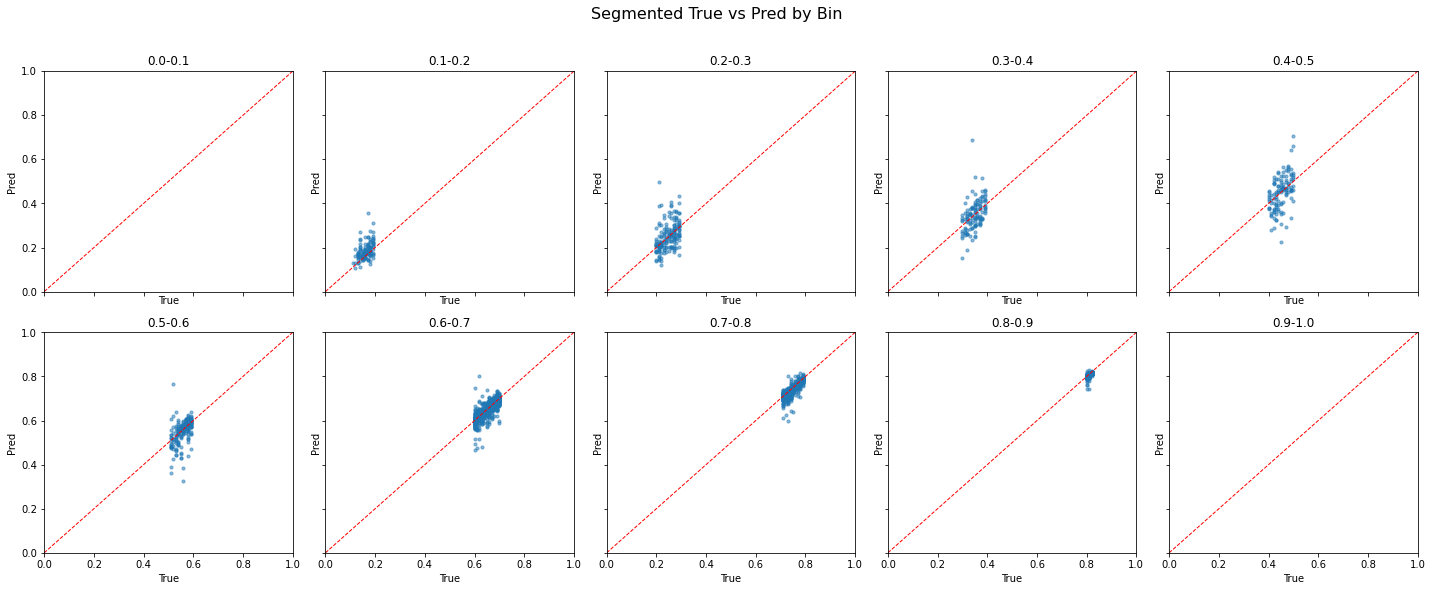

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# === 自定义 log-cosh loss ===
def log_cosh_loss(y_true, y_pred):
    return tf.reduce_mean(tf.math.log(tf.cosh(y_pred - y_true)))

# === 构建 Stacked LSTM 模型 ===
model_stacked_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),
    Dense(1)
])

# === 使用 log-cosh loss 编译模型 ===
model_stacked_lstm.compile(optimizer='adam', loss=log_cosh_loss)

# === 训练模型 ===
model_stacked_lstm.fit(
    X_seq_train, y_train,
    epochs=600, batch_size=32,
    verbose=2
)

# === 预测并评估 ===
y_pred_stacked = model_stacked_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_stacked)


Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing 

Epoch 102/600
407/407 - 2s - loss: 5.6248e-04 - 2s/epoch - 6ms/step
Epoch 103/600
407/407 - 2s - loss: 5.5103e-04 - 2s/epoch - 6ms/step
Epoch 104/600
407/407 - 3s - loss: 5.1933e-04 - 3s/epoch - 6ms/step
Epoch 105/600
407/407 - 2s - loss: 5.1444e-04 - 2s/epoch - 6ms/step
Epoch 106/600
407/407 - 3s - loss: 4.8372e-04 - 3s/epoch - 7ms/step
Epoch 107/600
407/407 - 3s - loss: 5.0386e-04 - 3s/epoch - 6ms/step
Epoch 108/600
407/407 - 3s - loss: 5.2522e-04 - 3s/epoch - 6ms/step
Epoch 109/600
407/407 - 2s - loss: 4.9654e-04 - 2s/epoch - 6ms/step
Epoch 110/600
407/407 - 2s - loss: 5.9653e-04 - 2s/epoch - 6ms/step
Epoch 111/600
407/407 - 2s - loss: 4.6007e-04 - 2s/epoch - 6ms/step
Epoch 112/600
407/407 - 3s - loss: 4.4893e-04 - 3s/epoch - 6ms/step
Epoch 113/600
407/407 - 2s - loss: 4.1745e-04 - 2s/epoch - 6ms/step
Epoch 114/600
407/407 - 3s - loss: 4.3128e-04 - 3s/epoch - 6ms/step
Epoch 115/600
407/407 - 2s - loss: 3.9843e-04 - 2s/epoch - 6ms/step
Epoch 116/600
407/407 - 2s - loss: 4.2228e-04 - 

Epoch 223/600
407/407 - 2s - loss: 1.5675e-04 - 2s/epoch - 6ms/step
Epoch 224/600
407/407 - 3s - loss: 1.3427e-04 - 3s/epoch - 6ms/step
Epoch 225/600
407/407 - 3s - loss: 1.4910e-04 - 3s/epoch - 6ms/step
Epoch 226/600
407/407 - 2s - loss: 1.2779e-04 - 2s/epoch - 6ms/step
Epoch 227/600
407/407 - 3s - loss: 1.2041e-04 - 3s/epoch - 6ms/step
Epoch 228/600
407/407 - 3s - loss: 1.2393e-04 - 3s/epoch - 6ms/step
Epoch 229/600
407/407 - 2s - loss: 1.2514e-04 - 2s/epoch - 6ms/step
Epoch 230/600
407/407 - 3s - loss: 1.3031e-04 - 3s/epoch - 6ms/step
Epoch 231/600
407/407 - 2s - loss: 1.5013e-04 - 2s/epoch - 6ms/step
Epoch 232/600
407/407 - 2s - loss: 1.4481e-04 - 2s/epoch - 6ms/step
Epoch 233/600
407/407 - 3s - loss: 1.4818e-04 - 3s/epoch - 6ms/step
Epoch 234/600
407/407 - 3s - loss: 1.3917e-04 - 3s/epoch - 6ms/step
Epoch 235/600
407/407 - 2s - loss: 1.1947e-04 - 2s/epoch - 6ms/step
Epoch 236/600
407/407 - 3s - loss: 1.1600e-04 - 3s/epoch - 6ms/step
Epoch 237/600
407/407 - 2s - loss: 1.2192e-04 - 

Epoch 344/600
407/407 - 3s - loss: 7.9501e-05 - 3s/epoch - 7ms/step
Epoch 345/600
407/407 - 3s - loss: 9.3595e-05 - 3s/epoch - 7ms/step
Epoch 346/600
407/407 - 3s - loss: 8.9991e-05 - 3s/epoch - 6ms/step
Epoch 347/600
407/407 - 3s - loss: 8.1805e-05 - 3s/epoch - 7ms/step
Epoch 348/600
407/407 - 3s - loss: 7.7310e-05 - 3s/epoch - 6ms/step
Epoch 349/600
407/407 - 3s - loss: 7.4171e-05 - 3s/epoch - 6ms/step
Epoch 350/600
407/407 - 2s - loss: 7.8675e-05 - 2s/epoch - 6ms/step
Epoch 351/600
407/407 - 3s - loss: 8.4130e-05 - 3s/epoch - 6ms/step
Epoch 352/600
407/407 - 2s - loss: 8.6600e-05 - 2s/epoch - 6ms/step
Epoch 353/600
407/407 - 2s - loss: 7.7911e-05 - 2s/epoch - 6ms/step
Epoch 354/600
407/407 - 2s - loss: 7.6770e-05 - 2s/epoch - 6ms/step
Epoch 355/600
407/407 - 2s - loss: 8.5303e-05 - 2s/epoch - 6ms/step
Epoch 356/600
407/407 - 3s - loss: 8.1815e-05 - 3s/epoch - 6ms/step
Epoch 357/600
407/407 - 3s - loss: 8.0688e-05 - 3s/epoch - 6ms/step
Epoch 358/600
407/407 - 2s - loss: 7.8552e-05 - 

Epoch 465/600
407/407 - 2s - loss: 5.4479e-05 - 2s/epoch - 6ms/step
Epoch 466/600
407/407 - 2s - loss: 5.5687e-05 - 2s/epoch - 6ms/step
Epoch 467/600
407/407 - 2s - loss: 5.9912e-05 - 2s/epoch - 6ms/step
Epoch 468/600
407/407 - 2s - loss: 6.7821e-05 - 2s/epoch - 6ms/step
Epoch 469/600
407/407 - 3s - loss: 6.4082e-05 - 3s/epoch - 6ms/step
Epoch 470/600
407/407 - 2s - loss: 6.3434e-05 - 2s/epoch - 6ms/step
Epoch 471/600
407/407 - 3s - loss: 5.6432e-05 - 3s/epoch - 6ms/step
Epoch 472/600
407/407 - 2s - loss: 5.5207e-05 - 2s/epoch - 6ms/step
Epoch 473/600
407/407 - 3s - loss: 5.7473e-05 - 3s/epoch - 6ms/step
Epoch 474/600
407/407 - 3s - loss: 6.2306e-05 - 3s/epoch - 6ms/step
Epoch 475/600
407/407 - 3s - loss: 6.6377e-05 - 3s/epoch - 6ms/step
Epoch 476/600
407/407 - 3s - loss: 5.7554e-05 - 3s/epoch - 6ms/step
Epoch 477/600
407/407 - 2s - loss: 5.4971e-05 - 2s/epoch - 6ms/step
Epoch 478/600
407/407 - 3s - loss: 6.0020e-05 - 3s/epoch - 7ms/step
Epoch 479/600
407/407 - 2s - loss: 5.3356e-05 - 

Epoch 586/600
407/407 - 3s - loss: 4.6129e-05 - 3s/epoch - 6ms/step
Epoch 587/600
407/407 - 2s - loss: 4.9956e-05 - 2s/epoch - 6ms/step
Epoch 588/600
407/407 - 2s - loss: 4.8213e-05 - 2s/epoch - 6ms/step
Epoch 589/600
407/407 - 3s - loss: 4.7482e-05 - 3s/epoch - 6ms/step
Epoch 590/600
407/407 - 2s - loss: 5.0654e-05 - 2s/epoch - 6ms/step
Epoch 591/600
407/407 - 2s - loss: 5.3538e-05 - 2s/epoch - 6ms/step
Epoch 592/600
407/407 - 2s - loss: 4.2389e-05 - 2s/epoch - 6ms/step
Epoch 593/600
407/407 - 3s - loss: 4.0297e-05 - 3s/epoch - 6ms/step
Epoch 594/600
407/407 - 2s - loss: 4.2354e-05 - 2s/epoch - 6ms/step
Epoch 595/600
407/407 - 3s - loss: 4.5577e-05 - 3s/epoch - 6ms/step
Epoch 596/600
407/407 - 3s - loss: 4.7656e-05 - 3s/epoch - 7ms/step
Epoch 597/600
407/407 - 2s - loss: 4.6272e-05 - 2s/epoch - 6ms/step
Epoch 598/600
407/407 - 2s - loss: 4.2882e-05 - 2s/epoch - 6ms/step
Epoch 599/600
407/407 - 3s - loss: 4.5387e-05 - 3s/epoch - 6ms/step
Epoch 600/600
407/407 - 2s - loss: 4.4129e-05 - 

,Value
Metric,
MSE,0.0010
MAE,0.0166
MAPE,0.0409
R2,0.9676


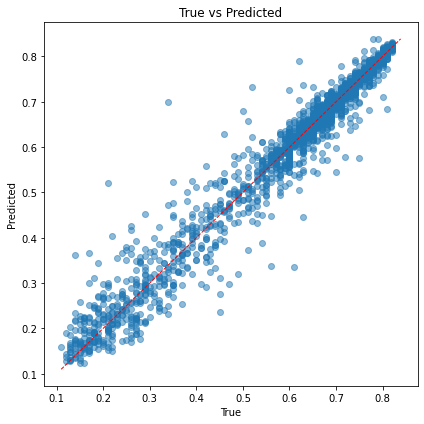


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,121,-5.0022,0.0026,0.0347,0.2197
0.2-0.3,169,-3.1725,0.0037,0.0438,0.1796
0.3-0.4,121,-4.4547,0.0040,0.0451,0.1309
0.4-0.5,120,-3.5352,0.0041,0.0460,0.1028
0.5-0.6,181,-2.2598,0.0021,0.0313,0.0570
0.6-0.7,1006,0.3792,0.0006,0.0148,0.0228
0.7-0.8,1046,0.5995,0.0002,0.0087,0.0116
0.8-0.9,487,-0.3589,0.0001,0.0040,0.0049



Average Segmented Metrics (skip NaN):
  R2:   -2.2256
  MSE:  0.0022
  MAE:  0.0285
  MAPE: 0.0912


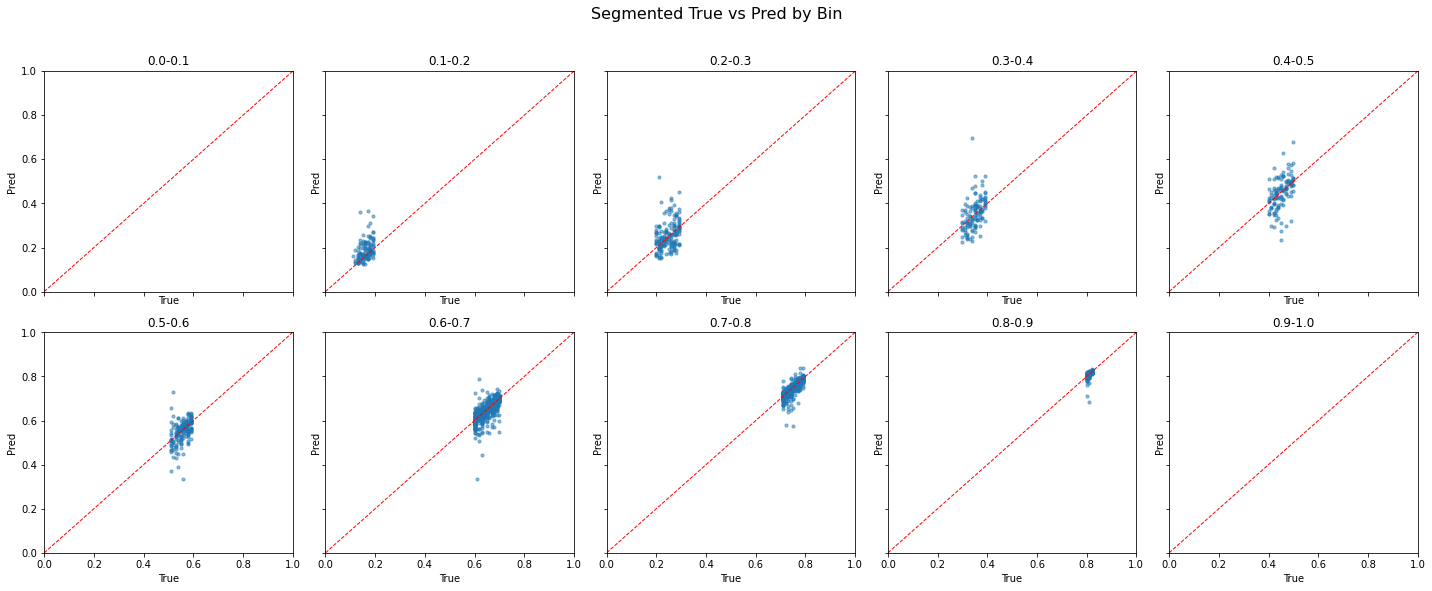

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# === 自定义 Weighted MSE Loss ===
def weighted_mse(y_true, y_pred):
    # 权重设计：值越小权重越大，这里用 1 / (y_true + ε) 形式
    epsilon = 1e-3  # 防止除以 0
    weights = 1.0 / (y_true + epsilon)
    squared_errors = tf.square(y_true - y_pred)
    weighted_errors = weights * squared_errors
    return tf.reduce_mean(weighted_errors)

# === 构建 Stacked LSTM 模型 ===
model_weighted = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),
    Dense(1)
])

# === 使用 Weighted MSE 编译模型 ===
model_weighted.compile(optimizer='adam', loss=weighted_mse)

# === 训练模型 ===
model_weighted.fit(
    X_seq_train, y_train,
    epochs=600, batch_size=32,
    verbose=2
)

# === 预测并评估 ===
y_pred_weighted = model_weighted.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_weighted)
